# Финальный проект: Анализ зависимости получения государственного финансирования некоммерческими организациями (НКО)

**Цель исследования:** Определить, существует ли зависимость между получением государственных грантов/субсидий/контрактов
некоммерческими организациями (НКО) и следующими факторами:
- Регион регистрации
- Возраст организации
- Экономическая деятельность (код ОКВЭД)

**Автор:** SkillFactory x Теплица
**Дата:** 2021 г.


## 1. Настройка окружения и загрузка данных


In [134]:
# 1.1 Импорт библиотек
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm
import warnings
from pathlib import Path
from datetime import datetime
import pickle
import os
from collections import defaultdict

warnings.filterwarnings('ignore')

# Настройка отображения pandas
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Настройка matplotlib для поддержки кириллицы
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('Библиотеки успешно загружены')


Библиотеки успешно загружены


In [135]:
# 1.2 Определение путей к данным
DATA_DIR = Path(r'D:\Skillbox_for_VS\python\data\openngo_temp\openngo_2021_26_08')
PICKLE_PATH = Path(r'D:\Skillbox_for_VS\python\data\openngo_temp\nko_df.pkl')
FOUNDATIONS_CSV_PATH = Path(r'D:\Skillbox_for_VS\python\data\openngo_temp\foundations_codes.csv')

JSON_FILES = sorted(DATA_DIR.glob('ngo_dump_*.json'))
print(f'Найдено JSON-файлов: {len(JSON_FILES)}')
for f in JSON_FILES:
    print(f'  {f.name}: {f.stat().st_size / 1e6:.1f} MB')


Найдено JSON-файлов: 15
  ngo_dump_01.json: 137.1 MB
  ngo_dump_02.json: 117.6 MB
  ngo_dump_03.json: 164.7 MB
  ngo_dump_04.json: 143.3 MB
  ngo_dump_05.json: 145.0 MB
  ngo_dump_06.json: 175.8 MB
  ngo_dump_07.json: 163.5 MB
  ngo_dump_08.json: 136.1 MB
  ngo_dump_09.json: 147.7 MB
  ngo_dump_10.json: 145.6 MB
  ngo_dump_11.json: 118.2 MB
  ngo_dump_12.json: 170.0 MB
  ngo_dump_13.json: 128.2 MB
  ngo_dump_14.json: 178.2 MB
  ngo_dump_15.json: 162.3 MB


In [136]:
# 1.3 Загрузка словаря ОКОПФ (основные типы ОПФ)
# Скачиваем файл foundations_codes.csv если его нет
if not FOUNDATIONS_CSV_PATH.exists():
    import urllib.request
    url = 'https://raw.githubusercontent.com/Teplitsa/CSRLab/main/Skillfactory%20x%20Teplitsa%20Lab/foundations_codes.csv'
    print('Скачивание foundations_codes.csv...')
    urllib.request.urlretrieve(url, FOUNDATIONS_CSV_PATH)
    print('Файл скачан')
else:
    print('Файл foundations_codes.csv уже существует')


Файл foundations_codes.csv уже существует


In [137]:
# 1.4 Функция для загрузки и парсинга JSON-файлов

def parse_ngo_record(record):
    """Извлекает нужные поля из JSON-объекта одной НКО."""
    income = record.get('incomeDetail', {}) or {}
    
    def safe_get(d, *keys):
        for k in keys:
            if isinstance(d, dict):
                d = d.get(k)
            else:
                return None
        return d
    
    def get_count(d, key):
        sub = d.get(key, {}) if isinstance(d, dict) else {}
        if not isinstance(sub, dict):
            sub = {}
        return safe_get(sub, 'totalCount') or 0
    
    def get_sum(d, key):
        sub = d.get(key, {}) if isinstance(d, dict) else {}
        if not isinstance(sub, dict):
            sub = {}
        return safe_get(sub, 'totalSum') or 0
    
    def parse_date(date_field):
        """Парсит дату из поля с $date."""
        if isinstance(date_field, dict):
            d = date_field.get('$date')
        elif isinstance(date_field, str):
            d = date_field
        else:
            return None
        if d:
            try:
                return pd.to_datetime(d[:10])
            except:
                return None
        return None
    
    opf = record.get('opf', {}) or {}
    main_okved = record.get('mainOkved', {}) or {}
    
    grants_cnt = get_count(income, 'grants')
    fed_cnt = get_count(income, 'fedSubsidies')
    c44_cnt = get_count(income, 'contracts44')
    c223_cnt = get_count(income, 'contracts223')
    c94_cnt = get_count(income, 'contracts94')
    
    grants_sum = get_sum(income, 'grants')
    fed_sum = get_sum(income, 'fedSubsidies')
    c44_sum = get_sum(income, 'contracts44')
    c223_sum = get_sum(income, 'contracts223')
    c94_sum = get_sum(income, 'contracts94')
    
    date_ogrn = parse_date(record.get('dateOgrn'))
    date_reg = parse_date(record.get('dateReg'))
    
    email = record.get('email')
    website = record.get('website') or record.get('website_punycode')
    
    return {
        'ogrn': record.get('ogrn'),
        'inn': record.get('inn'),
        'kpp': record.get('kpp'),
        'fullName': record.get('fullName'),
        'shortName': record.get('shortName'),
        'regionName': record.get('regionName'),
        'regionCode': record.get('regionCode'),
        'egrulStatus': record.get('egrulStatus'),
        'minjustForm': record.get('minjustForm'),
        'minjustStatus': record.get('minjustStatus'),
        'opf_name': safe_get(opf, 'name'),
        'opf_code': safe_get(opf, 'code'),
        'okved_name': safe_get(main_okved, 'name'),
        'okved_code': safe_get(main_okved, 'code'),
        'incomeTotal': record.get('incomeTotal', 0),
        'grants_totalCount': grants_cnt,
        'grants_totalSum': grants_sum,
        'fedSubsidies_totalCount': fed_cnt,
        'fedSubsidies_totalSum': fed_sum,
        'contracts44_totalCount': c44_cnt,
        'contracts44_totalSum': c44_sum,
        'contracts223_totalCount': c223_cnt,
        'contracts223_totalSum': c223_sum,
        'contracts94_totalCount': c94_cnt,
        'contracts94_totalSum': c94_sum,
        'dateOgrn': date_ogrn,
        'dateReg': date_reg,
        'hasRegionalSupport': record.get('hasRegionalSupport', False),
        'has_email': 1 if email else 0,
        'has_website': 1 if website else 0,
    }

print('Функция parse_ngo_record определена')


Функция parse_ngo_record определена


In [138]:
# 1.5 Функция загрузки данных из JSON

def load_data(force_reload=False):
    """Загружает данные из JSON-файлов или pickle."""
    if not force_reload and PICKLE_PATH.exists():
        print('Загрузка данных из pickle...')
        with open(PICKLE_PATH, 'rb') as f:
            df = pickle.load(f)
        print(f'Загружено {len(df):,} записей из pickle')
        return df

    print(f'Загрузка данных из {len(JSON_FILES)} JSON-файлов...')
    all_records = []
    for fpath in tqdm(JSON_FILES, desc='Чтение файлов'):
        with open(fpath, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    record = json.loads(line)
                    parsed = parse_ngo_record(record)
                    all_records.append(parsed)
                except Exception:
                    continue

    df = pd.DataFrame(all_records)

    print(f'Сохранение {len(df):,} записей в pickle...')
    with open(PICKLE_PATH, 'wb') as f:
        pickle.dump(df, f)

    return df

print('Функция load_data определена')

# Загружаем данные
# Для полной загрузки всех 15 файлов используем force_reload=True
df = load_data(force_reload=True)


Функция load_data определена
Загрузка данных из 15 JSON-файлов...


Чтение файлов: 100%|██████████| 15/15 [07:12<00:00, 28.83s/it]


Сохранение 747,034 записей в pickle...


In [139]:
# 1.6 Предварительный просмотр данных
print(f'Размер датасета: {df.shape[0]:,} строк x {df.shape[1]} колонок')
df.head(10)


Размер датасета: 747,034 строк x 30 колонок


,ogrn,inn,kpp,fullName,shortName,regionName,regionCode,egrulStatus,minjustForm,minjustStatus,opf_name,opf_code,okved_name,okved_code,incomeTotal,grants_totalCount,grants_totalSum,fedSubsidies_totalCount,fedSubsidies_totalSum,contracts44_totalCount,contracts44_totalSum,contracts223_totalCount,contracts223_totalSum,contracts94_totalCount,contracts94_totalSum,dateOgrn,dateReg,hasRegionalSupport,has_email,has_website
0,1207800141790,7841091168,784101001,МЕЖРЕГИОНАЛЬНАЯ АНТРОПОСОФСКАЯ МЕДИЦИНСКАЯ АСС...,"""АМА""",Санкт-Петербург,78,Действует,"Объединения (союз, ассоциация) юридических лиц",Зарегистрирована,Ассоциации (союзы),20600,Деятельность профессиональных членских организ...,94.12,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2020-10-30,NaT,False,0,0
1,1207700349152,7720646827,772001001,"ФОНД ""СОДЕЙСТВИЕ ДУХОВНОМУ РАЗВИТИЮ ЧЕЛОВЕКА ""...","ФОНД ""УНИВЕРСАЛИСТ М""",Москва,77,Действует,Некоммерческий фонд,Зарегистрирована,Фонды,70400,"Предоставление прочих финансовых услуг, кроме ...",64.99,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2020-09-23,NaT,False,0,0
2,1207800011430,7813642543,781301001,"КОЛЛЕГИЯ АДВОКАТОВ ""САНКТ-ПЕТЕРБУРГСКАЯ КОЛЛЕГ...",None,Санкт-Петербург,78,Действует,Коллегия адвокатов,Зарегистрирована,Коллегии адвокатов,20616,Деятельность в области права,69.10,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2020-02-03,NaT,False,0,0
3,1207700348976,7733359837,773301001,"ТОВАРИЩЕСТВО СОБСТВЕННИКОВ НЕДВИЖИМОСТИ ""ЛУГИН...","ТСН ""ЛУГИНИНО ПАРК""",Москва,77,Действует,None,None,Товарищества собственников недвижимости,20700,Управление недвижимым имуществом за вознагражд...,68.32,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2020-09-23,NaT,False,0,0
4,1207800081500,7813645343,781301001,"АВТОНОМНАЯ НЕКОММЕРЧЕСКАЯ ОРГАНИЗАЦИЯ ""ЦЕНТР С...","АНО ""ЦЕНТР ""ПЕТЕРБУРГФОРУМ""",Санкт-Петербург,78,Действует,Автономная некоммерческая организация,Зарегистрирована,Автономные некоммерческие организации,71400,Деятельность по организации конференций и выст...,82.30,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2020-07-08,NaT,False,0,0
5,1207700350440,7720646859,772001001,"АВТОНОМНАЯ НЕКОММЕРЧЕСКАЯ ОРГАНИЗАЦИЯ ""ЦЕНТР К...","АНО ""ПЕРВЫЙ ПОДАРОК""",Москва,77,Действует,Автономная некоммерческая организация,Зарегистрирована,Автономные некоммерческие организации,71400,Предоставление прочих социальных услуг без обе...,88.99,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2020-09-23,NaT,False,0,0
6,1207700330056,9717094552,771701001,"РЕЛИГИОЗНАЯ ОРГАНИЗАЦИЯ ""ПАТРИАРШИЙ ЭКЗАРХАТ Ю...",None,Москва,77,Действует,Религиозная организация,Зарегистрирована,Религиозные организации,71500,Деятельность религиозных организаций,94.91,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2020-09-09,NaT,False,0,0
7,1207700437966,7713478804,771301001,"АВТОНОМНАЯ НЕКОММЕРЧЕСКАЯ ОРГАНИЗАЦИЯ ""НАЦИОНА...","АНО""НЦПИКН""",Москва,77,Действует,Автономная некоммерческая организация,Зарегистрирована,Автономные некоммерческие организации,71400,Консультирование по вопросам коммерческой деят...,70.22,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2020-11-18,NaT,False,0,0
8,1201200004609,1218003160,121801001,МЕСТНАЯ РЕЛИГИОЗНАЯ ОРГАНИЗАЦИЯ ПРАВОСЛАВНЫЙ П...,None,Республика Марий Эл,12,Действует,Религиозная организация,Зарегистрирована,Религиозные организации,71500,Деятельность религиозных организаций,94.91,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2020-11-23,NaT,False,0,0
9,1207500003260,7522004909,752201001,"АВТОНОМНАЯ НЕКОММЕРЧЕСКАЯ ОРГАНИЗАЦИЯ ""ВОЕННО-...","АНО ""ВОЕННО-СПОРТИВНЫЙ КЛУБ КОДАР""",Забайкальский край,75,Действует,Автономная некоммерческая организация,Зарегистрирована,Автономные некоммерческие организации,71400,Деятельность спортивных клубов,93.12,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,2020-07-13,NaT,False,0,0


In [140]:
# 1.7 Типы данных и оптимизация памяти

def optimize_dtypes(df):
    """Оптимизирует типы данных для экономии памяти."""
    memory_before = df.memory_usage(deep=True).sum() / 1024**2
    
    # Числовые колонки - понижаем разрядность
    for col in df.select_dtypes(include=['int64']).columns:
        c_min, c_max = df[col].min(), df[col].max()
        if c_min >= 0:
            if c_max < 255:
                df[col] = df[col].astype('uint8')
            elif c_max < 65535:
                df[col] = df[col].astype('uint16')
            elif c_max < 4294967295:
                df[col] = df[col].astype('uint32')
        else:
            if c_min > -128 and c_max < 127:
                df[col] = df[col].astype('int8')
            elif c_min > -32768 and c_max < 32767:
                df[col] = df[col].astype('int16')
            elif c_min > -2147483648 and c_max < 2147483647:
                df[col] = df[col].astype('int32')
    
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    
    # Категориальные колонки с небольшим числом уникальных значений
    for col in df.select_dtypes(include=['object']).columns:
        nunique = df[col].nunique()
        if nunique < 100:
            df[col] = df[col].astype('category')
    
    memory_after = df.memory_usage(deep=True).sum() / 1024**2
    print(f'Память до оптимизации: {memory_before:.1f} MB')
    print(f'Память после оптимизации: {memory_after:.1f} MB')
    print(f'Экономия: {(1 - memory_after/memory_before)*100:.1f}%')
    return df

df = optimize_dtypes(df)
df.info()


Память до оптимизации: 1308.8 MB
Память после оптимизации: 908.9 MB
Экономия: 30.6%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747034 entries, 0 to 747033
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   ogrn                     747034 non-null  object        
 1   inn                      744430 non-null  object        
 2   kpp                      743372 non-null  object        
 3   fullName                 747034 non-null  object        
 4   shortName                597793 non-null  object        
 5   regionName               747009 non-null  category      
 6   regionCode               747034 non-null  category      
 7   egrulStatus              747034 non-null  category      
 8   minjustForm              462302 non-null  category      
 9   minjustStatus            462302 non-null  category      
 10  opf_name                 746619 non-null  object        

## 2. Очистка данных и создание признаков (Feature Engineering)


In [141]:
# 2.1 Фильтрация: только действующие организации
print(f'Всего записей до фильтрации: {len(df):,}')
print(f'\nРаспределение egrulStatus:')
print(df['egrulStatus'].value_counts())

df = df[df['egrulStatus'] == 'Действует'].copy()
print(f'\nПосле фильтрации (только "Действует"): {len(df):,} записей')


Всего записей до фильтрации: 747,034

Распределение egrulStatus:
egrulStatus
Ликвидирована    406134
Действует        340900
Name: count, dtype: int64

После фильтрации (только "Действует"): 340,900 записей


In [142]:
# 2.2 Удаление записей с полным отсутствием ключевых полей
key_fields = ['ogrn', 'inn', 'fullName', 'regionCode', 'opf_code', 'okved_code']
before = len(df)
df = df.dropna(subset=key_fields, how='all').copy()
removed = before - len(df)
print(f'Удалено записей с пустыми ключевыми полями: {removed}')
print(f'Осталось: {len(df):,} записей')


Удалено записей с пустыми ключевыми полями: 0
Осталось: 340,900 записей


In [143]:
# 2.3 Создание целевой переменной
# has_gov_funding = 1 если есть хотя бы один грант/субсидия/контракт
funding_cols = [
    'grants_totalCount', 'fedSubsidies_totalCount',
    'contracts44_totalCount', 'contracts223_totalCount', 'contracts94_totalCount'
]

df['gov_funding_total_count'] = df[funding_cols].sum(axis=1)
df['has_gov_funding'] = (df['gov_funding_total_count'] > 0).astype(np.uint8)

funding_sum_cols = [
    'grants_totalSum', 'fedSubsidies_totalSum',
    'contracts44_totalSum', 'contracts223_totalSum', 'contracts94_totalSum'
]
df['gov_funding_total_sum'] = df[funding_sum_cols].sum(axis=1)

print(f'Распределение целевой переменной:')
print(f'  Не получали госфинансирование: {((df["has_gov_funding"] == 0).sum()):,} ({(df["has_gov_funding"] == 0).mean()*100:.1f}%)')
print(f'  Получали госфинансирование:    {((df["has_gov_funding"] == 1).sum()):,} ({(df["has_gov_funding"] == 1).mean()*100:.1f}%)')
print(f'  Доля получающих: {df["has_gov_funding"].mean():.4f}')


Распределение целевой переменной:
  Не получали госфинансирование: 311,453 (91.4%)
  Получали госфинансирование:    29,447 (8.6%)
  Доля получающих: 0.0864


In [144]:
# 2.4 Создание признака возраста организации
# Данные за 2021 год
REFERENCE_YEAR = 2021

def extract_year(date_series):
    """Извлекает год из pd.Timestamp."""
    return date_series.dt.year

df['reg_year'] = extract_year(df['dateOgrn'])
df['age_years'] = REFERENCE_YEAR - df['reg_year']

# Проверяем аномальные значения возраста
print(f'Описательная статистика возраста организации:')
print(df['age_years'].describe())
print(f'\nКоличество записей с age_years <= 0: {(df["age_years"] <= 0).sum()}')
print(f'Количество записей с age_years > 100: {(df["age_years"] > 100).sum()}')

# Обрабатываем аномалии: заменяем отрицательный/нулевой возраст на NaN, >100 на NaN
df.loc[df['age_years'] <= 0, 'age_years'] = np.nan
df.loc[df['age_years'] > 100, 'age_years'] = np.nan
print(f'После обработки аномалий осталось {df["age_years"].notna().sum():,} записей с корректным возрастом')


Описательная статистика возраста организации:
count    340900.000000
mean         11.647325
std           6.476490
min           0.000000
25%           6.000000
50%          13.000000
75%          18.000000
max          19.000000
Name: age_years, dtype: float64

Количество записей с age_years <= 0: 8708
Количество записей с age_years > 100: 0
После обработки аномалий осталось 332,192 записей с корректным возрастом


In [145]:
# Маппинг числовых кодов ОКВЭД2 (ОК 029-2014) по первым 2 цифрам
# Первые 2 цифры числового кода соответствуют секции экономической деятельности
okved_numeric_to_section = {
    1: 'A', 2: 'A', 3: 'A',
    5: 'B', 6: 'B', 7: 'B', 8: 'B', 9: 'B',
    10: 'C', 11: 'C', 12: 'C', 13: 'C', 14: 'C', 15: 'C', 16: 'C', 17: 'C', 18: 'C',
    19: 'C', 20: 'C', 21: 'C', 22: 'C', 23: 'C', 24: 'C', 25: 'C', 26: 'C', 27: 'C',
    28: 'C', 29: 'C', 30: 'C', 31: 'C', 32: 'C', 33: 'C',
    35: 'D',
    36: 'E', 37: 'E', 38: 'E', 39: 'E',
    41: 'F', 42: 'F', 43: 'F',
    45: 'G', 46: 'G', 47: 'G',
    49: 'H', 50: 'H', 51: 'H', 52: 'H', 53: 'H',
    55: 'I', 56: 'I',
    58: 'J', 59: 'J', 60: 'J', 61: 'J', 62: 'J', 63: 'J',
    64: 'K', 65: 'K', 66: 'K',
    68: 'L',
    69: 'M', 70: 'M', 71: 'M', 72: 'M', 73: 'M', 74: 'M', 75: 'M',
    77: 'N', 78: 'N', 79: 'N', 80: 'N', 81: 'N', 82: 'N',
    84: 'O',
    85: 'P',
    86: 'Q', 87: 'Q', 88: 'Q',
    90: 'R', 91: 'R', 92: 'R', 93: 'R',
    94: 'S', 95: 'S', 96: 'S',
    97: 'T', 98: 'T',
    99: 'U'
}

okved_numeric_to_name = {}
for codes, name in {
    tuple(range(1, 4)): 'Сельское хозяйство',
    tuple(range(5, 10)): 'Добыча полезных ископаемых',
    tuple(range(10, 34)): 'Обрабатывающие производства',
    (35,): 'Обеспечение энергией',
    tuple(range(36, 40)): 'Водоснабжение, водоотведение',
    tuple(range(41, 44)): 'Строительство',
    tuple(range(45, 48)): 'Торговля оптовая и розничная',
    tuple(range(49, 54)): 'Транспортировка и хранение',
    tuple(range(55, 57)): 'Гостиницы и общественное питание',
    tuple(range(58, 64)): 'Информация и связь',
    tuple(range(64, 67)): 'Финансовая и страховая деятельность',
    (68,): 'Операции с недвижимостью',
    tuple(range(69, 76)): 'Профессиональная, научная и техническая деятельность',
    tuple(range(77, 83)): 'Административная деятельность',
    (84,): 'Госуправление и военная безопасность',
    (85,): 'Образование',
    tuple(range(86, 89)): 'Здравоохранение и социальные услуги',
    tuple(range(90, 94)): 'Культура, спорт, организация досуга',
    tuple(range(94, 97)): 'Прочие услуги',
    tuple(range(97, 99)): 'Деятельность домохозяйств',
    (99,): 'Деятельность экстерриториальных организаций'
}.items():
    for c in codes:
        okved_numeric_to_name[str(c).zfill(2)] = name

def get_okved_section(code):
    """Определяет секцию ОКВЭД по коду. Поддерживает буквенные (ОКВЭД2) и числовые (старый ОКВЭД) коды."""
    if pd.isna(code) or not isinstance(code, str):
        return 'Unknown'
    code = code.strip().upper()
    if not code:
        return 'Unknown'
    first_char = code[0]
    if first_char.isalpha():
        return first_char
    # Числовой код — маппим по первым 2 цифрам
    two_digit_str = code[:2].lstrip('0') if code[:2] != '0' else '0'
    if two_digit_str == '':
        two_digit_str = '0'
    try:
        two_digit = int(two_digit_str)
        return okved_numeric_to_section.get(two_digit, 'Other')
    except ValueError:
        return 'Other'

def get_okved_section_name(section, okved_code):
    """Возвращает название секции ОКВЭД."""
    if section in okved_sections:
        return okved_sections[section]
    # Числовой код — маппим через lookup
    if pd.notna(okved_code):
        code_str = str(okved_code).strip().upper()
        two_digit = code_str[:2].lstrip('0') if code_str[:2] != '0' else '0'
        if two_digit == '':
            two_digit = '0'
        if two_digit in okved_numeric_to_name:
            return okved_numeric_to_name[two_digit]
    return 'Прочее'

okved_sections = {
    'A': 'Сельское хозяйство',
    'B': 'Добыча полезных ископаемых',
    'C': 'Обрабатывающие производства',
    'D': 'Обеспечение энергией',
    'E': 'Водоснабжение, водоотведение',
    'F': 'Строительство',
    'G': 'Торговля оптовая и розничная',
    'H': 'Транспортировка и хранение',
    'I': 'Гостиницы и общественное питание',
    'J': 'Информация и связь',
    'K': 'Финансовая и страховая деятельность',
    'L': 'Операции с недвижимостью',
    'M': 'Профессиональная, научная и техническая деятельность',
    'N': 'Административная деятельность',
    'O': 'Госуправление и военная безопасность',
    'P': 'Образование',
    'Q': 'Здравоохранение и социальные услуги',
    'R': 'Культура, спорт, организация досуга',
    'S': 'Прочие услуги',
    'T': 'Деятельность домохозяйств',
    'U': 'Деятельность экстерриториальных организаций'
}

df['okved_section'] = df['okved_code'].apply(get_okved_section)

# Добавляем название секции
df['okved_section_name'] = df.apply(lambda r: get_okved_section_name(r['okved_section'], r['okved_code']), axis=1)

print('Распределение по секциям ОКВЭД (топ-15):')
print(df['okved_section_name'].value_counts().head(15))


Распределение по секциям ОКВЭД (топ-15):
okved_section_name
Прочие услуги                                           115264
Операции с недвижимостью                                 65200
Транспортировка и хранение                               38562
Культура, спорт, организация досуга                      19685
Образование                                              17843
Профессиональная, научная и техническая деятельность     16144
Финансовая и страховая деятельность                      14649
Сельское хозяйство                                       12415
Прочее                                                   11198
Здравоохранение и социальные услуги                      10074
Торговля оптовая и розничная                              3911
Строительство                                             3773
Информация и связь                                        3046
Административная деятельность                             2858
Обрабатывающие производства                               

In [146]:
# 2.6 Группировка редких секций ОКВЭД в "Другое"
# Оставляем только основные секции, остальные объединяем
section_counts = df['okved_section'].value_counts()
major_sections = section_counts[section_counts >= 500].index.tolist()
print(f'Основных секций (>= 1000 записей): {len(major_sections)}')
print(f'Редких секций: {len(section_counts) - len(major_sections)}')

df['okved_section_grouped'] = df['okved_section'].apply(
    lambda x: x if x in major_sections else 'Другое'
).astype('category')

print(f'\nРаспределение после группировки:')
print(df['okved_section_grouped'].value_counts())


Основных секций (>= 1000 записей): 18
Редких секций: 4

Распределение после группировки:
okved_section_grouped
S          115264
L           65200
H           38562
R           19685
P           17843
M           16144
K           14649
A           12415
Unknown     11198
Q           10074
G            3911
F            3773
J            3046
N            2858
C            2342
O            2152
D             668
E             573
Другое        543
Name: count, dtype: int64


In [147]:
# 2.7 Создание категорий ОПФ (организационно-правовой формы)
def categorize_opf(name):
    """Группирует организационно-правовые формы в категории."""
    if pd.isna(name):
        return 'Неизвестно'
    name = str(name).lower()
    if 'общественная' in name or 'обществен' in name:
        return 'Общественная организация'
    elif 'благотвори' in name:
        return 'Благотворительный фонд'
    elif 'автономная некоммерческая' in name:
        return 'Автономная НКО'
    elif 'фонд' in name and 'благотвори' not in name:
        return 'Фонд (неблаготворительный)'
    elif 'ассоциац' in name or 'союз' in name:
        return 'Ассоциация / Союз'
    elif 'некоммерческое партн' in name:
        return 'Некоммерческое партнерство'
    elif 'учреждение' in name or 'учредител' in name:
        return 'Учреждение'
    elif 'казач' in name:
        return 'Казачье общество'
    elif 'община' in name or 'корен' in name:
        return 'Община коренных народов'
    elif 'профсоюз' in name or 'профессиональный союз' in name:
        return 'Профсоюз'
    elif 'товарищество' in name or 'тсж' in name or 'садовод' in name or 'огород' in name:
        return 'Товарищество собственников'
    elif 'нотариаль' in name or 'адвокат' in name:
        return 'Нотариальная / Адвокатская палата'
    elif 'религиоз' in name or 'церков' in name:
        return 'Религиозная организация'
    elif 'потребительский кооператив' in name or 'потребительское общество' in name or 'кооператив' in name:
        return 'Потребительский кооператив'
    elif 'территориальное общественное самоуправление' in name or 'тос' in name:
        return 'ТОС'
    elif 'коллегия адвокатов' in name or 'адвокатское бюро' in name or 'юридическая консультация' in name:
        return 'Адвокатское образование'
    elif 'торгово-промышлен' in name or 'тпп' in name:
        return 'Торгово-промышленная палата'
    elif 'саморегулируем' in name or 'сро' in name:
        return 'СРО'
    else:
        return 'Прочая НКО'

df['opf_category'] = df['opf_name'].apply(categorize_opf).astype('category')

print('Распределение категорий ОПФ:')
print(df['opf_category'].value_counts())


Распределение категорий ОПФ:
opf_category
Прочая НКО                           94493
Потребительский кооператив           72693
Общественная организация             67885
Религиозная организация              31828
Ассоциация / Союз                    26492
Товарищество собственников           20859
Благотворительный фонд                9406
Фонд (неблаготворительный)            8823
Нотариальная / Адвокатская палата     4038
Казачье общество                      2536
Община коренных народов               1626
СРО                                    126
Торгово-промышленная палата             63
Автономная НКО                          14
Некоммерческое партнерство              14
Неизвестно                               4
Name: count, dtype: int64


In [148]:
# 2.8 Создание федеральных округов по коду региона
# Коды регионов РФ: https://ru.wikipedia.org/wiki/Коды_субъектов_Российской_Федерации

federal_districts = {
    # Центральный федеральный округ
    'Центральный': ['31', '32', '33', '36', '46', '48', '50', '57', '60', '62', '67', '68', '69', '71', '76', '77', '78', '79', '99', '97', '40'],
    # Северо-Западный федеральный округ
    'Северо-Западный': ['10', '11', '29', '35', '39', '47', '51', '53', '60', '78', '83', '86', '87', '29'],
    # Южный федеральный округ
    'Южный': ['1', '8', '23', '30', '34', '61', '80', '84', '91', '93', '95'],
    # Северо-Кавказский федеральный округ
    'Северо-Кавказский': ['5', '6', '7', '9', '15', '20', '26', '64', '95'],
    # Приволжский федеральный округ
    'Приволжский': ['2', '12', '13', '14', '16', '18', '21', '43', '52', '56', '58', '63', '64', '66', '73', '75', '89'],
    # Уральский федеральный округ
    'Уральский': ['45', '72', '74', '86', '89', '66'],
    # Сибирский федеральный округ
    'Сибирский': ['4', '19', '22', '24', '38', '42', '54', '55', '65', '70', '75', '84', '88', '91'],
    # Дальневосточный федеральный округ
    'Дальневосточный': ['25', '27', '28', '41', '49', '65', '75', '79', '80', '81', '82', '87', '88', '89', '90', '99'],
}

# Для обратного поиска
region_to_district = {}
for district, codes in federal_districts.items():
    for code in codes:
        region_to_district[code] = district

def get_federal_district(region_code):
    """Определяет федеральный округ по коду региона."""
    if pd.isna(region_code):
        return 'Неизвестно'
    code = str(int(region_code)) if isinstance(region_code, (int, float)) else str(region_code).strip()
    return region_to_district.get(code, 'Неизвестно')

df['region_federal_district'] = df['regionCode'].apply(get_federal_district).astype('category')

print('Распределение по федеральным округам:')
print(df['region_federal_district'].value_counts())


Распределение по федеральным округам:
region_federal_district
Центральный          95619
Приволжский          56597
Сибирский            43521
Северо-Западный      37825
Неизвестно           33284
Уральский            24560
Южный                24407
Дальневосточный      19074
Северо-Кавказский     6013
Name: count, dtype: int64


In [149]:
# 2.9 Логарифмирование дохода
df['log_income'] = np.log1p(df['incomeTotal'].fillna(0).astype('float32'))

print('Статистика incomeTotal:')
print(df['incomeTotal'].describe())
print(f'\nДоля записей с нулевым доходом: {(df["incomeTotal"] == 0).mean()*100:.1f}%')


Статистика incomeTotal:
count    3.409000e+05
mean     1.108670e+07
std      2.297373e+09
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.227756e+12
Name: incomeTotal, dtype: float64

Доля записей с нулевым доходом: 91.4%


In [150]:
# 2.10 Финальная проверка пропущенных значений
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
print('Процент пропущенных значений по колонкам (топ-20):')
print(missing_pct[missing_pct > 0].head(20))


Процент пропущенных значений по колонкам (топ-20):
dateReg          65.922851
minjustStatus    30.776767
minjustForm      30.776767
shortName        14.757407
okved_code        3.284834
okved_name        3.284834
age_years         2.554415
kpp               0.029334
inn               0.028454
opf_code          0.007627
opf_name          0.001173
regionName        0.000293
dtype: float64


## 3. Разведочный анализ данных (EDA)


In [151]:
# 3.1 Базовая статистика датасета
print(f'\n{"="*60}')
print('ОСНОВНЫЕ ХАРАКТЕРИСТИКИ ДАТАСЕТА')
print(f'{"="*60}')
print(f'Количество записей: {len(df):,}')
print(f'Количество признаков: {df.shape[1]}')
print(f'Количество регионов: {df["regionName"].nunique()}')
print(f'Количество ОКВЭД-секций: {df["okved_section"].nunique()}')
print(f'Количество категорий ОПФ: {df["opf_category"].nunique()}')
print(f'Количество федеральных округов: {df["region_federal_district"].nunique()}')

print(f'\n{"="*60}')
print('ЧИСЛОВЫЕ ПРИЗНАКИ')
print(f'{"="*60}')
print(df[['incomeTotal', 'log_income', 'age_years', 'gov_funding_total_count', 'gov_funding_total_sum']].describe())



ОСНОВНЫЕ ХАРАКТЕРИСТИКИ ДАТАСЕТА
Количество записей: 340,900
Количество признаков: 41
Количество регионов: 86
Количество ОКВЭД-секций: 22
Количество категорий ОПФ: 16
Количество федеральных округов: 9

ЧИСЛОВЫЕ ПРИЗНАКИ
        incomeTotal     log_income      age_years  gov_funding_total_count  gov_funding_total_sum
count  3.409000e+05  340900.000000  332192.000000            340900.000000           3.409000e+05
mean   1.108670e+07       1.223561      11.952645                 1.123236           1.108670e+07
std    2.297373e+09       4.034366       6.276549                18.434658           2.297373e+09
min    0.000000e+00       0.000000       1.000000                 0.000000           0.000000e+00
25%    0.000000e+00       0.000000       6.000000                 0.000000           0.000000e+00
50%    0.000000e+00       0.000000      13.000000                 0.000000           0.000000e+00
75%    0.000000e+00       0.000000      18.000000                 0.000000           0.000000

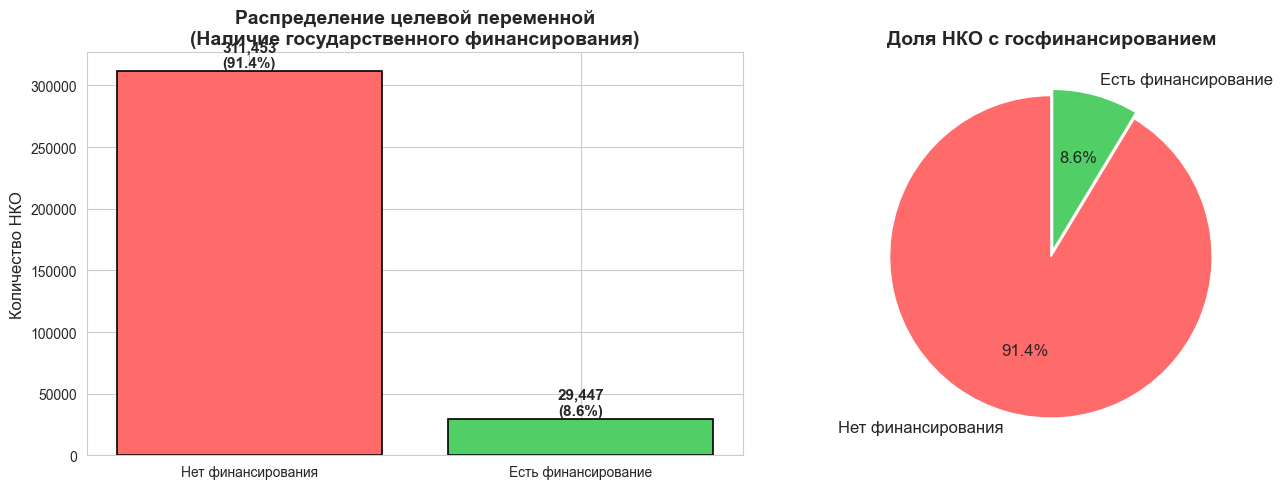


Дисбаланс классов: 10.58:1
(потребуется балансировка при обучении модели)


In [152]:
# 3.2 Распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График распределения
target_counts = df['has_gov_funding'].value_counts()
colors = ['#ff6b6b', '#51cf66']
axes[0].bar(['Нет финансирования', 'Есть финансирование'], target_counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Распределение целевой переменной\n(Наличие государственного финансирования)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Количество НКО', fontsize=12)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + max(target_counts.values)*0.01, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')

# Круговая диаграмма
axes[1].pie(target_counts.values, labels=['Нет финансирования', 'Есть финансирование'],
            autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.02, 0.02),
            textprops={'fontsize': 12})
axes[1].set_title('Доля НКО с госфинансированием', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nДисбаланс классов: {target_counts.values[0]/target_counts.values[1]:.2f}:1')
print('(потребуется балансировка при обучении модели)')


Пропущенные значения в данных:
      Колонка  Количество пропусков  Доля (%)
      dateReg                224731     65.92
  minjustForm                104918     30.78
minjustStatus                104918     30.78
    shortName                 50308     14.76
   okved_code                 11198      3.28
   okved_name                 11198      3.28
    age_years                  8708      2.55
          inn                    97      0.03
          kpp                   100      0.03
     opf_code                    26      0.01
   regionName                     1      0.00
     opf_name                     4      0.00


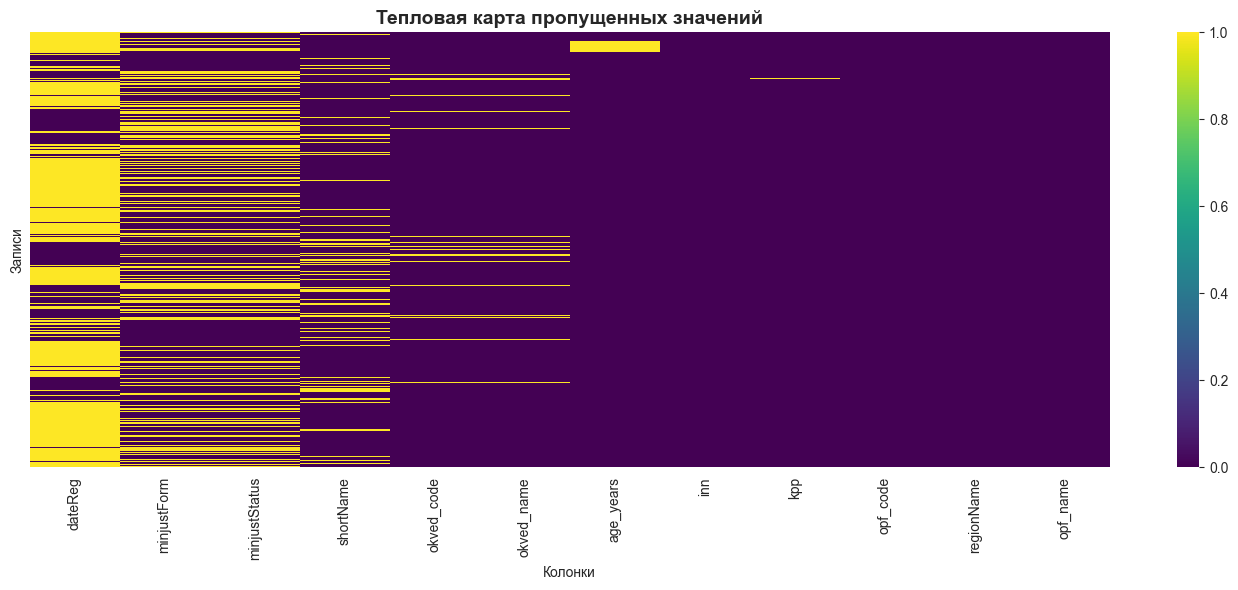

In [153]:
# 3.3 Анализ пропущенных значений
missing_df = df.isna().sum().reset_index()
missing_df.columns = ['Колонка', 'Количество пропусков']
missing_df['Доля (%)'] = (missing_df['Количество пропусков'] / len(df) * 100).round(2)
missing_df = missing_df[missing_df['Количество пропусков'] > 0].sort_values('Доля (%)', ascending=False)

print('Пропущенные значения в данных:')
print(missing_df.to_string(index=False))

# Тепловая карта пропусков (только для колонок с пропусками)
if len(missing_df) > 0:
    cols_with_missing = missing_df['Колонка'].tolist()
    plt.figure(figsize=(14, 6))
    sns.heatmap(df[cols_with_missing].isna(), yticklabels=False, cbar=True, cmap='viridis')
    plt.title('Тепловая карта пропущенных значений', fontsize=14, fontweight='bold')
    plt.xlabel('Колонки')
    plt.ylabel('Записи')
    plt.tight_layout()
    plt.show()


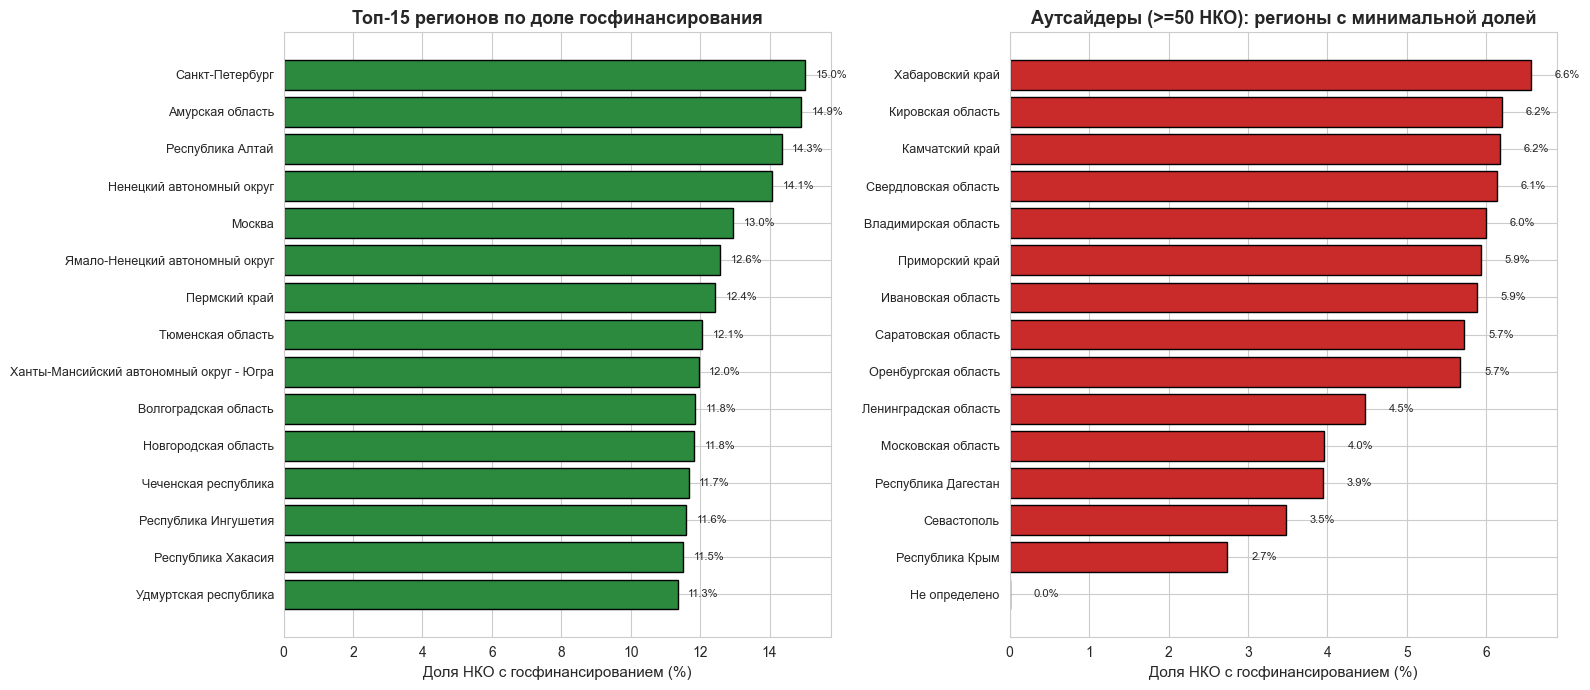


Регионы-лидеры (по доле финансирования):
                                          Всего НКО  Доля с финансированием  Кол-во с финансированием
regionName                                                                                           
Санкт-Петербург                               13086                  0.1502                      1966
Амурская область                               1080                  0.1491                       161
Республика Алтай                                864                  0.1435                       124
Ненецкий автономный округ                       199                  0.1407                        28
Москва                                        37293                  0.1295                      4828
Ямало-Ненецкий автономный округ                1208                  0.1258                       152
Пермский край                                  6773                  0.1243                       842
Тюменская область                       

In [154]:
# 3.4 Анализ по регионам
# Топ-15 регионов по доле получающих госфинансирование
region_stats = df.groupby('regionName', observed=True).agg({
    'has_gov_funding': ['count', 'mean', 'sum']
}).round(4)
region_stats.columns = ['Всего НКО', 'Доля с финансированием', 'Кол-во с финансированием']
region_stats = region_stats.sort_values('Доля с финансированием', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Топ-15 регионов с наибольшей долей финансирования
top_regions = region_stats.head(15)
axes[0].barh(range(len(top_regions)), top_regions['Доля с финансированием'].values * 100, color='#2b8a3e', edgecolor='black')
axes[0].set_yticks(range(len(top_regions)))
axes[0].set_yticklabels(top_regions.index, fontsize=9)
axes[0].set_xlabel('Доля НКО с госфинансированием (%)', fontsize=11)
axes[0].set_title('Топ-15 регионов по доле госфинансирования', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(top_regions['Доля с финансированием'].values * 100):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

# Топ-15 регионов с наименьшей долей финансирования
bottom_regions = region_stats[region_stats['Всего НКО'] >= 50].tail(15)
axes[1].barh(range(len(bottom_regions)), bottom_regions['Доля с финансированием'].values * 100, color='#c92a2a', edgecolor='black')
axes[1].set_yticks(range(len(bottom_regions)))
axes[1].set_yticklabels(bottom_regions.index, fontsize=9)
axes[1].set_xlabel('Доля НКО с госфинансированием (%)', fontsize=11)
axes[1].set_title('Аутсайдеры (>=50 НКО): регионы с минимальной долей', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(bottom_regions['Доля с финансированием'].values * 100):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\nРегионы-лидеры (по доле финансирования):')
print(region_stats.head(10).to_string())
print(f'\nРегионы-аутсайдеры (>=50 НКО):')
print(region_stats[region_stats['Всего НКО'] >= 50].tail(10).to_string())


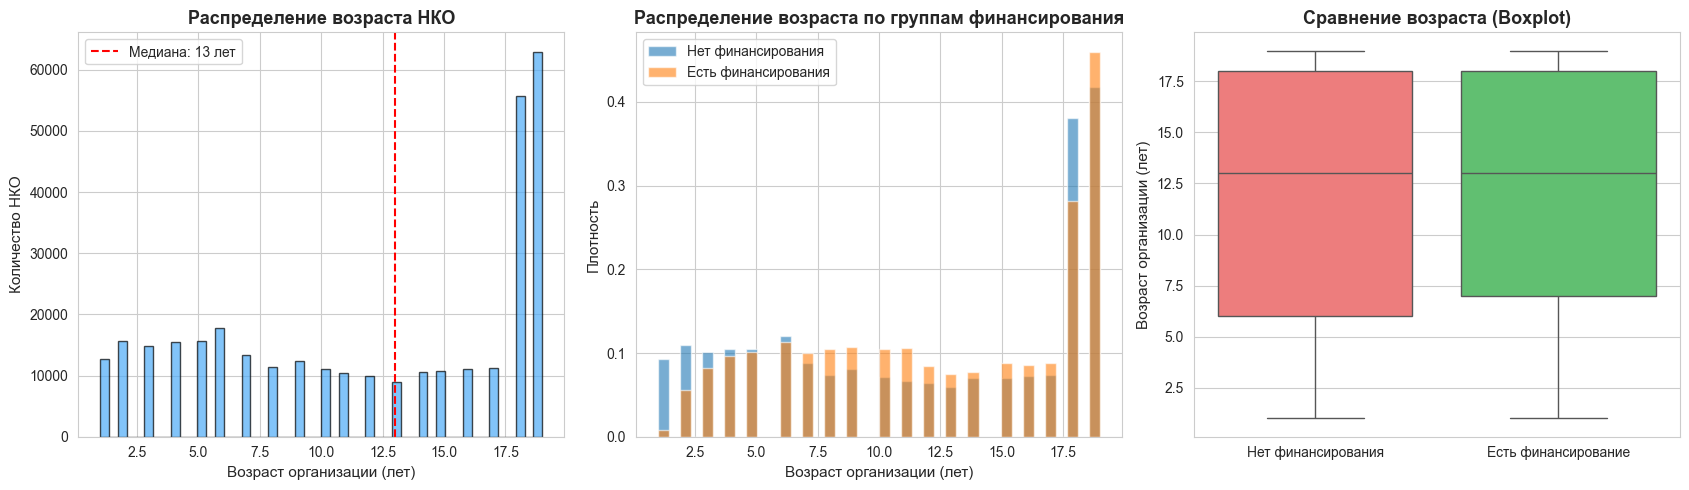

Статистика возраста по группам финансирования:
                    count   mean   std  min  25%   50%   75%   max
has_gov_funding                                                   
0                302758.0  11.90  6.33  1.0  6.0  13.0  18.0  19.0
1                 29434.0  12.49  5.66  1.0  7.0  13.0  18.0  19.0


In [155]:
# 3.5 Анализ возраста организации
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Гистограмма возраста
axes[0].hist(df['age_years'].dropna(), bins=50, color='#4dabf7', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Возраст организации (лет)', fontsize=11)
axes[0].set_ylabel('Количество НКО', fontsize=11)
axes[0].set_title('Распределение возраста НКО', fontsize=13, fontweight='bold')
axes[0].axvline(df['age_years'].median(), color='red', linestyle='--', label=f'Медиана: {df["age_years"].median():.0f} лет')
axes[0].legend()

# Возраст по группам финансирования
for funding in [0, 1]:
    data = df[df['has_gov_funding'] == funding]['age_years'].dropna()
    axes[1].hist(data, bins=40, alpha=0.6, label=f'{"Есть" if funding else "Нет"} финансирования', density=True)
axes[1].set_xlabel('Возраст организации (лет)', fontsize=11)
axes[1].set_ylabel('Плотность', fontsize=11)
axes[1].set_title('Распределение возраста по группам финансирования', fontsize=13, fontweight='bold')
axes[1].legend()

# Boxplot возраста по группам
df_box = df[['has_gov_funding', 'age_years']].dropna().copy()
df_box['has_gov_funding'] = df_box['has_gov_funding'].map({0: 'Нет финансирования', 1: 'Есть финансирование'})
sns.boxplot(data=df_box, x='has_gov_funding', y='age_years', ax=axes[2], palette=['#ff6b6b', '#51cf66'])
axes[2].set_xlabel('')
axes[2].set_ylabel('Возраст организации (лет)', fontsize=11)
axes[2].set_title('Сравнение возраста (Boxplot)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Статистика возраста по группам
print('Статистика возраста по группам финансирования:')
print(df.groupby('has_gov_funding', observed=True)['age_years'].describe().round(2))


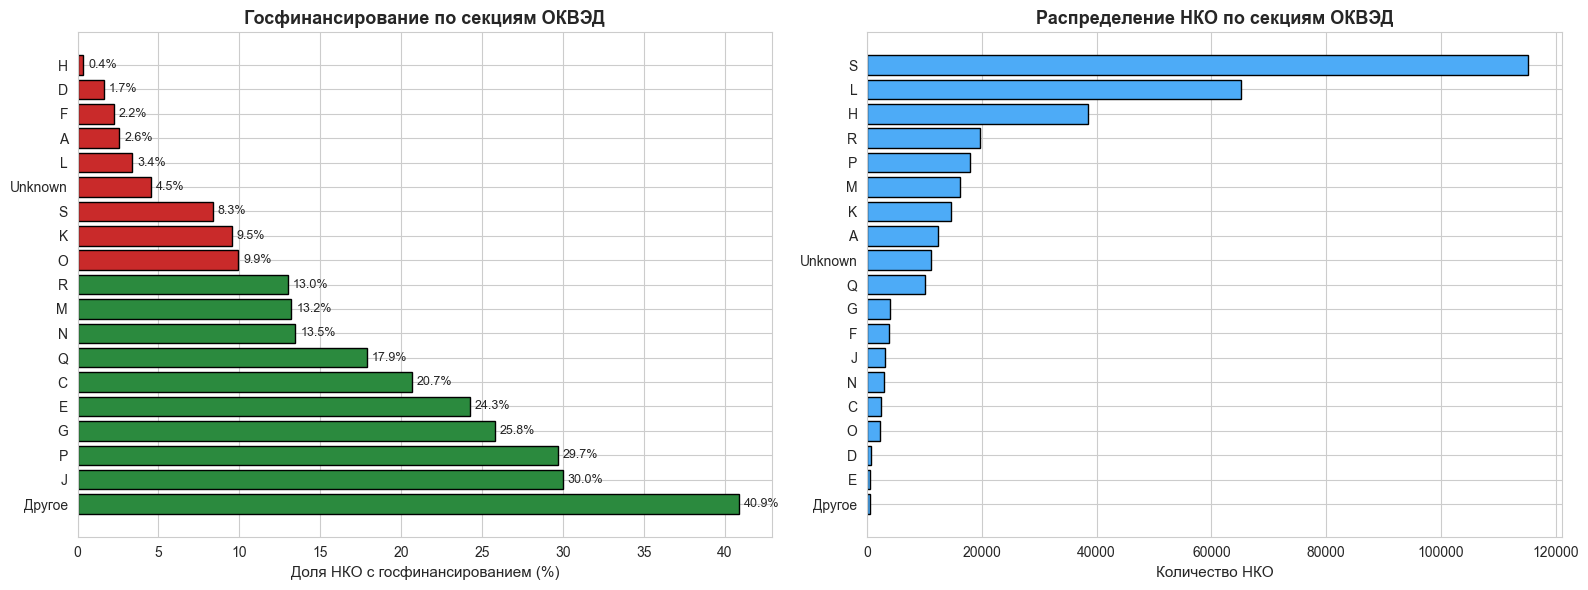


Секции ОКВЭД с наибольшей долей госфинансирования:
                       Всего НКО  Доля с финансированием  Кол-во с финансированием
okved_section_grouped                                                             
Другое                       543                  0.4088                       222
J                           3046                  0.3001                       914
P                          17843                  0.2970                      5300
G                           3911                  0.2582                      1010
E                            573                  0.2426                       139
C                           2342                  0.2067                       484
Q                          10074                  0.1789                      1802
N                           2858                  0.1347                       385
M                          16144                  0.1322                      2134
R                          19685   

In [156]:
# 3.6 Анализ по ОКВЭД (экономическая деятельность)
okved_stats = df.groupby('okved_section_grouped', observed=True).agg({
    'has_gov_funding': ['count', 'mean', 'sum']
}).round(4)
okved_stats.columns = ['Всего НКО', 'Доля с финансированием', 'Кол-во с финансированием']
okved_stats = okved_stats.sort_values('Доля с финансированием', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График: доля финансирования по секциям ОКВЭД
colors_okved = ['#2b8a3e' if v >= okved_stats['Доля с финансированием'].median() else '#c92a2a' 
                for v in okved_stats['Доля с финансированием'].values]
bars = axes[0].barh(range(len(okved_stats)), okved_stats['Доля с финансированием'].values * 100, 
                    color=colors_okved, edgecolor='black')
axes[0].set_yticks(range(len(okved_stats)))
axes[0].set_yticklabels(okved_stats.index, fontsize=10)
axes[0].set_xlabel('Доля НКО с госфинансированием (%)', fontsize=11)
axes[0].set_title('Госфинансирование по секциям ОКВЭД', fontsize=13, fontweight='bold')
for i, v in enumerate(okved_stats['Доля с финансированием'].values * 100):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# Количество НКО по секциям
okved_count = df['okved_section_grouped'].value_counts().sort_values(ascending=True)
axes[1].barh(range(len(okved_count)), okved_count.values, color='#4dabf7', edgecolor='black')
axes[1].set_yticks(range(len(okved_count)))
axes[1].set_yticklabels(okved_count.index, fontsize=10)
axes[1].set_xlabel('Количество НКО', fontsize=11)
axes[1].set_title('Распределение НКО по секциям ОКВЭД', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nСекции ОКВЭД с наибольшей долей госфинансирования:')
print(okved_stats.head(10).to_string())
print('\nСекции ОКВЭД с наименьшей долей госфинансирования:')
print(okved_stats.tail(10).to_string())


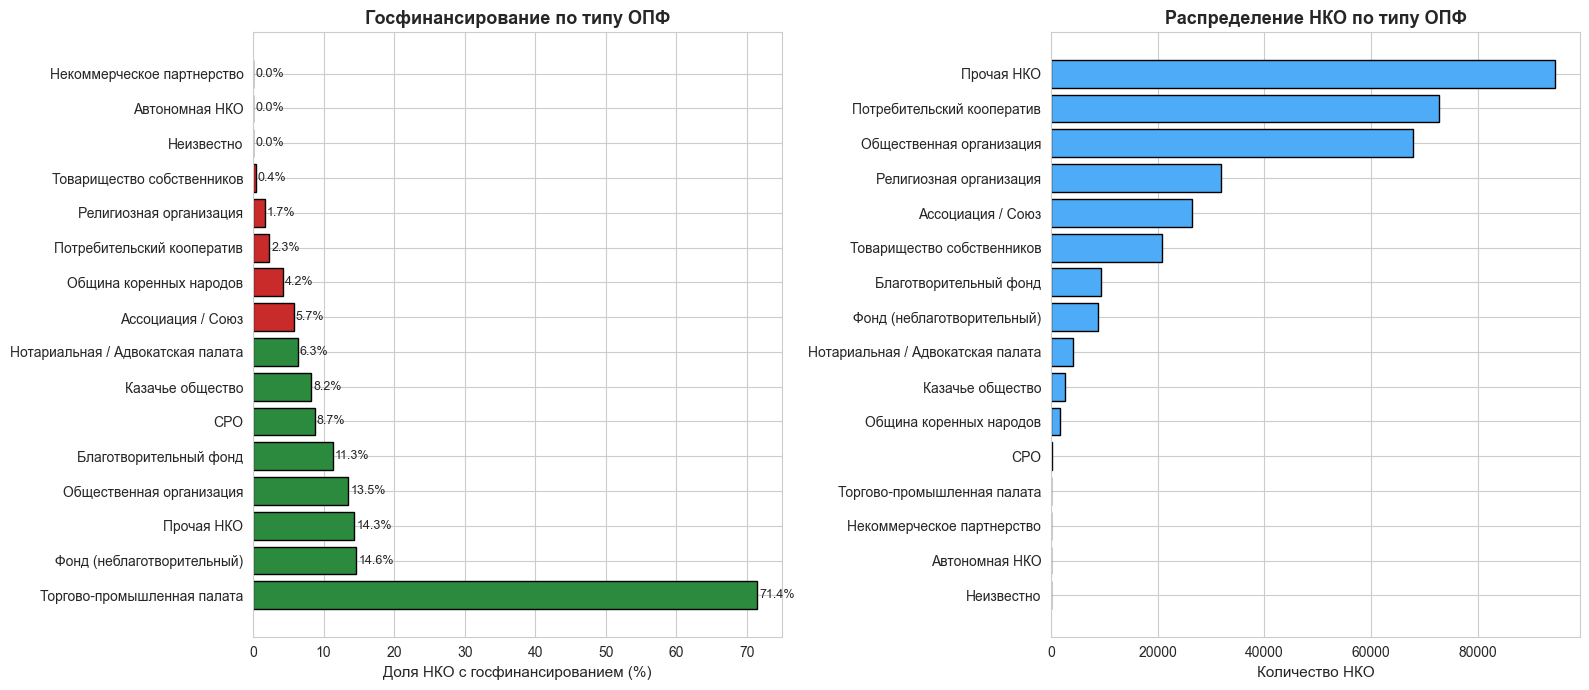


Распределение госфинансирования по ОПФ:
                                   Всего НКО  Доля с финансированием  Кол-во с финансированием
opf_category                                                                                  
Торгово-промышленная палата               63                  0.7143                        45
Фонд (неблаготворительный)              8823                  0.1461                      1289
Прочая НКО                             94493                  0.1435                     13564
Общественная организация               67885                  0.1350                      9166
Благотворительный фонд                  9406                  0.1134                      1067
СРО                                      126                  0.0873                        11
Казачье общество                        2536                  0.0824                       209
Нотариальная / Адвокатская палата       4038                  0.0634                       256
Ассоциаци

In [157]:
# 3.7 Анализ по ОПФ (организационно-правовая форма)
opf_stats = df.groupby('opf_category', observed=True).agg({
    'has_gov_funding': ['count', 'mean', 'sum']
}).round(4)
opf_stats.columns = ['Всего НКО', 'Доля с финансированием', 'Кол-во с финансированием']
opf_stats = opf_stats.sort_values('Доля с финансированием', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_opf = ['#2b8a3e' if v >= opf_stats['Доля с финансированием'].median() else '#c92a2a'
              for v in opf_stats['Доля с финансированием'].values]
bars = axes[0].barh(range(len(opf_stats)), opf_stats['Доля с финансированием'].values * 100,
                    color=colors_opf, edgecolor='black')
axes[0].set_yticks(range(len(opf_stats)))
axes[0].set_yticklabels(opf_stats.index, fontsize=10)
axes[0].set_xlabel('Доля НКО с госфинансированием (%)', fontsize=11)
axes[0].set_title('Госфинансирование по типу ОПФ', fontsize=13, fontweight='bold')
for i, v in enumerate(opf_stats['Доля с финансированием'].values * 100):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

opf_count = df['opf_category'].value_counts().sort_values(ascending=True)
axes[1].barh(range(len(opf_count)), opf_count.values, color='#4dabf7', edgecolor='black')
axes[1].set_yticks(range(len(opf_count)))
axes[1].set_yticklabels(opf_count.index, fontsize=10)
axes[1].set_xlabel('Количество НКО', fontsize=11)
axes[1].set_title('Распределение НКО по типу ОПФ', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nРаспределение госфинансирования по ОПФ:')
print(opf_stats.to_string())


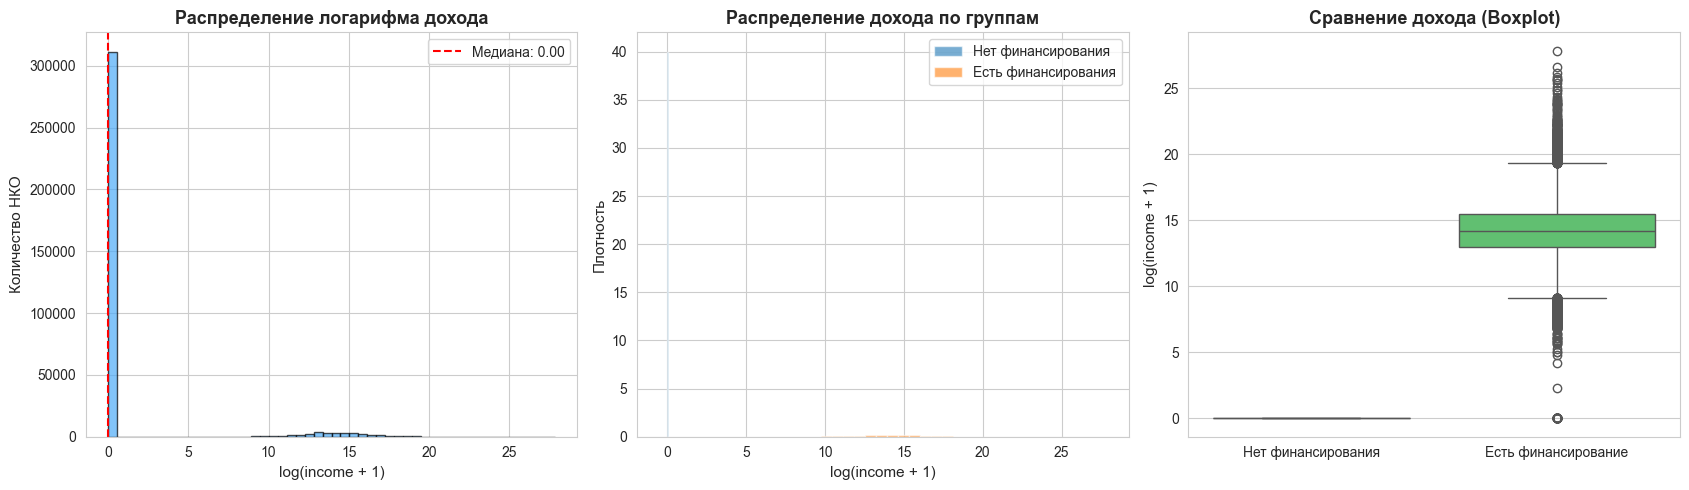

In [158]:
# 3.8 Анализ дохода
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Распределение дохода
axes[0].hist(df['log_income'].values, bins=50, color='#4dabf7', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('log(income + 1)', fontsize=11)
axes[0].set_ylabel('Количество НКО', fontsize=11)
axes[0].set_title('Распределение логарифма дохода', fontsize=13, fontweight='bold')
axes[0].axvline(df['log_income'].median(), color='red', linestyle='--', label=f'Медиана: {df["log_income"].median():.2f}')
axes[0].legend()

# Доход по группам финансирования
for funding in [0, 1]:
    data = df[df['has_gov_funding'] == funding]['log_income'].dropna()
    axes[1].hist(data, bins=40, alpha=0.6, label=f'{"Есть" if funding else "Нет"} финансирования', density=True)
axes[1].set_xlabel('log(income + 1)', fontsize=11)
axes[1].set_ylabel('Плотность', fontsize=11)
axes[1].set_title('Распределение дохода по группам', fontsize=13, fontweight='bold')
axes[1].legend()

# Boxplot дохода
df_box_inc = df[['has_gov_funding', 'log_income']].dropna().copy()
df_box_inc['has_gov_funding'] = df_box_inc['has_gov_funding'].map({0: 'Нет финансирования', 1: 'Есть финансирование'})
sns.boxplot(data=df_box_inc, x='has_gov_funding', y='log_income', ax=axes[2], palette=['#ff6b6b', '#51cf66'])
axes[2].set_xlabel('')
axes[2].set_ylabel('log(income + 1)', fontsize=11)
axes[2].set_title('Сравнение дохода (Boxplot)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


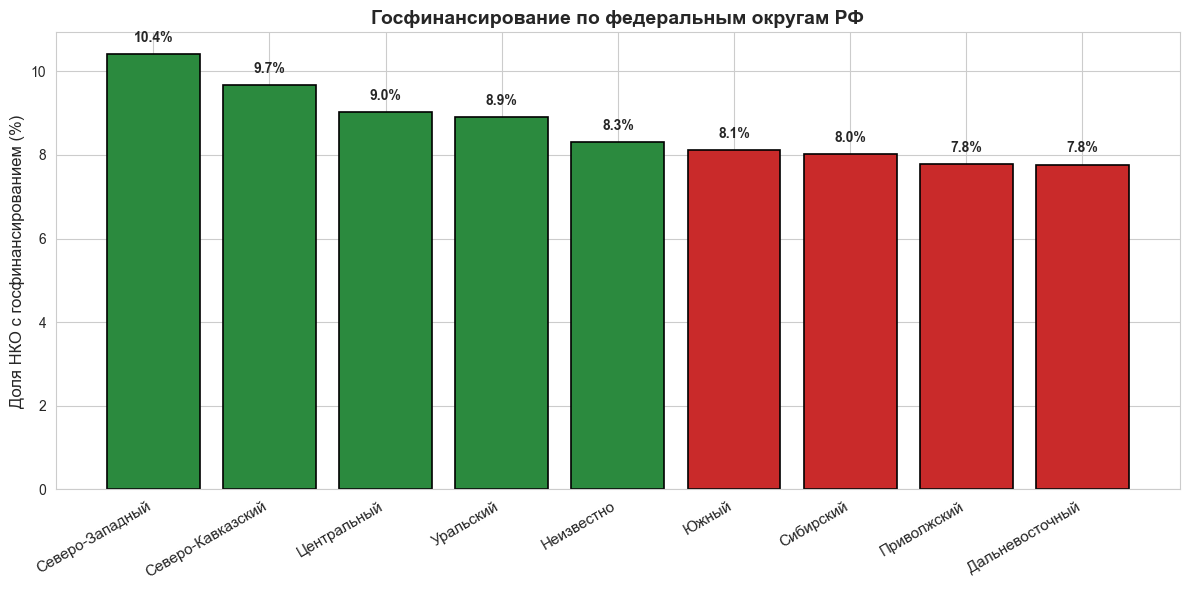

Госфинансирование по федеральным округам:
                         Всего НКО  Доля с финансированием  Кол-во с финансированием
region_federal_district                                                             
Северо-Западный              37825                  0.1041                      3939
Северо-Кавказский             6013                  0.0966                       581
Центральный                  95619                  0.0902                      8629
Уральский                    24560                  0.0890                      2185
Неизвестно                   33284                  0.0830                      2761
Южный                        24407                  0.0811                      1979
Сибирский                    43521                  0.0802                      3491
Приволжский                  56597                  0.0778                      4401
Дальневосточный              19074                  0.0776                      1481


In [159]:
# 3.9 Анализ по федеральным округам
district_stats = df.groupby('region_federal_district', observed=True).agg({
    'has_gov_funding': ['count', 'mean', 'sum']
}).round(4)
district_stats.columns = ['Всего НКО', 'Доля с финансированием', 'Кол-во с финансированием']
district_stats = district_stats.sort_values('Доля с финансированием', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_dist = ['#2b8a3e' if v >= district_stats['Доля с финансированием'].median() else '#c92a2a'
               for v in district_stats['Доля с финансированием'].values]
bars = ax.bar(range(len(district_stats)), district_stats['Доля с финансированием'].values * 100,
             color=colors_dist, edgecolor='black', linewidth=1.2)
ax.set_xticks(range(len(district_stats)))
ax.set_xticklabels(district_stats.index, fontsize=11, rotation=30, ha='right')
ax.set_ylabel('Доля НКО с госфинансированием (%)', fontsize=12)
ax.set_title('Госфинансирование по федеральным округам РФ', fontsize=14, fontweight='bold')
for i, v in enumerate(district_stats['Доля с финансированием'].values * 100):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print('Госфинансирование по федеральным округам:')
print(district_stats.to_string())


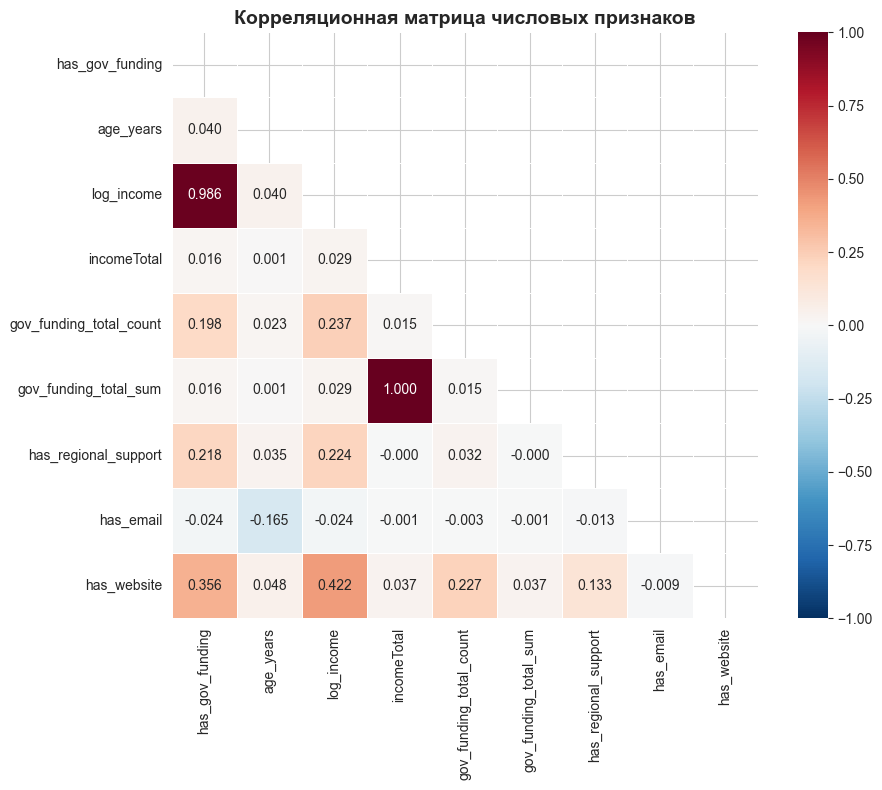

In [160]:
# 3.10 Корреляционная матрица числовых признаков
numeric_cols_for_corr = [
    'has_gov_funding', 'age_years', 'log_income', 'incomeTotal',
    'gov_funding_total_count', 'gov_funding_total_sum',
    'hasRegionalSupport', 'has_email', 'has_website'
]

# Переименуем колонку для корреляции
corr_df = df[numeric_cols_for_corr].copy()
corr_df.columns = ['has_gov_funding', 'age_years', 'log_income', 'incomeTotal',
                'gov_funding_total_count', 'gov_funding_total_sum',
                'has_regional_support', 'has_email', 'has_website']
# исправляем если колонка называется иначе

# Заполняем NaN
corr_df = corr_df.fillna(0)

plt.figure(figsize=(10, 8))
corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


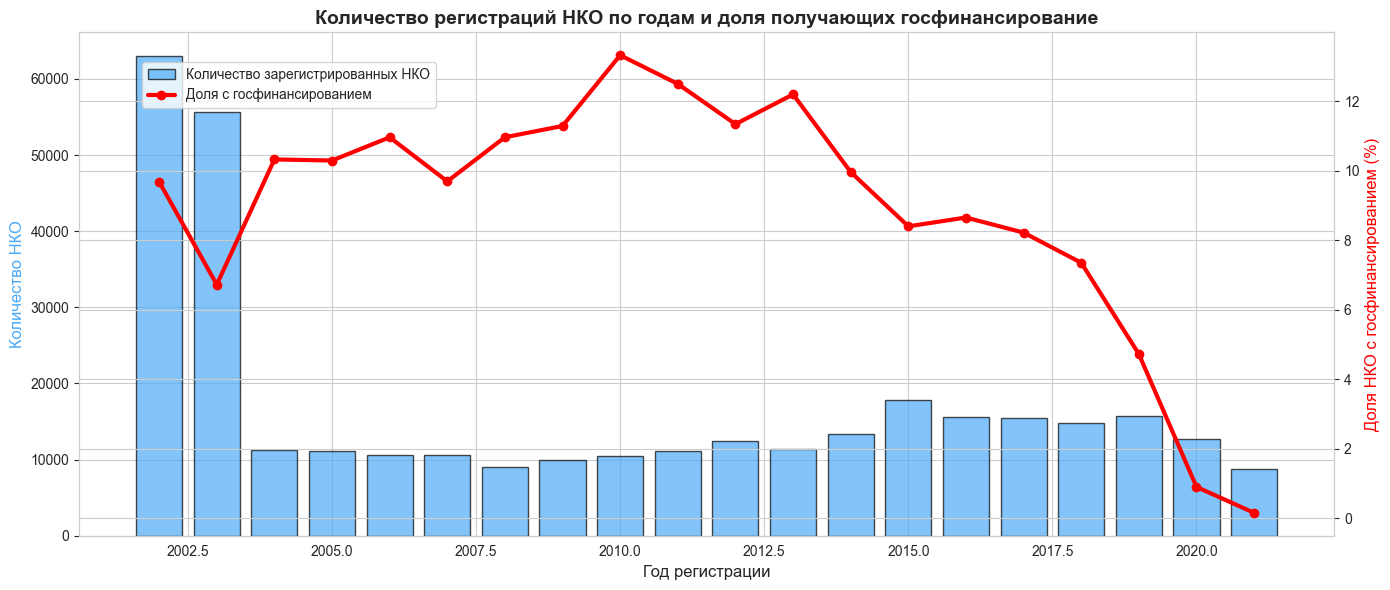

In [161]:
# 3.11 Динамика регистрации НКО по годам
yearly = df.groupby('reg_year', observed=True).agg({
    'has_gov_funding': ['count', 'mean']
}).dropna()
yearly.columns = ['count', 'funding_rate']
yearly = yearly[yearly.index >= 1990]

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(yearly.index, yearly['count'], color='#4dabf7', edgecolor='black', alpha=0.7, label='Количество зарегистрированных НКО')
ax1.set_xlabel('Год регистрации', fontsize=12)
ax1.set_ylabel('Количество НКО', fontsize=12, color='#4dabf7')

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['funding_rate'] * 100, 'r-', linewidth=3, marker='o', label='Доля с госфинансированием')
ax2.set_ylabel('Доля НКО с госфинансированием (%)', fontsize=12, color='red')

plt.title('Количество регистраций НКО по годам и доля получающих госфинансирование', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()


## 4. Статистический анализ гипотез


In [162]:
# 4.1 Импорт статистических библиотек
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal, pointbiserialr
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest

print('Статистические библиотеки загружены')


Статистические библиотеки загружены


In [163]:
# 4.2 Тест: Зависимость региона и госфинансирования
# H0: Регион регистрации НЕ влияет на получение госфинансирования
# H1: Регион регистрации влияет на получение госфинансирования

# Строим таблицу сопряженности
contingency_region = pd.crosstab(df['regionName'], df['has_gov_funding'])
print(f'Размер таблицы сопряженности: {contingency_region.shape[0]} регионов x {contingency_region.shape[1]} категорий')

# Chi-square test
chi2_stat_region, p_val_region, dof_region, expected_region = chi2_contingency(contingency_region)

print(f'\n{"="*50}')
print('ТЕСТ ХИ-КВАДРАТ: РЕГИОН vs ГОСФИНАНСИРОВАНИЕ')
print(f'{"="*50}')
print(f'Chi2-статистика: {chi2_stat_region:.2f}')
print(f'Степени свободы: {dof_region}')
print(f'P-значение: {p_val_region:.2e}')
alpha = 0.05
if p_val_region < alpha:
    print(f'\nРЕЗУЛЬТАТ: p < {alpha} - ОТВЕРГАЕМ H0')
    print('=> Существует статистически значимая зависимость между регионом и получением госфинансирования')
else:
    print(f'\nРЕЗУЛЬТАТ: p >= {alpha} - НЕ можем отвергнуть H0')

# V Крамера для оценки силы связи
n = contingency_region.sum().sum()
phi2 = chi2_stat_region / n
r, k = contingency_region.shape
v_cramer_region = np.sqrt(phi2 / min(k-1, r-1))
print(f'V Крамера (сила связи): {v_cramer_region:.4f}')
if v_cramer_region < 0.1:
    print('Связь очень слабая')
elif v_cramer_region < 0.3:
    print('Связь слабая')
elif v_cramer_region < 0.5:
    print('Связь умеренная')
else:
    print('Связь сильная')


Размер таблицы сопряженности: 86 регионов x 2 категорий

ТЕСТ ХИ-КВАДРАТ: РЕГИОН vs ГОСФИНАНСИРОВАНИЕ
Chi2-статистика: 3897.84
Степени свободы: 85
P-значение: 0.00e+00

РЕЗУЛЬТАТ: p < 0.05 - ОТВЕРГАЕМ H0
=> Существует статистически значимая зависимость между регионом и получением госфинансирования
V Крамера (сила связи): 0.1069
Связь слабая


In [164]:
# 4.3 Тест: Зависимость ОКВЭД и госфинансирования
# H0: Экономическая деятельность (ОКВЭД) НЕ влияет на получение госфинансирования
# H1: Экономическая деятельность влияет на получение госфинансирования

contingency_okved = pd.crosstab(df['okved_section_grouped'], df['has_gov_funding'])
print(f'Таблица сопряженности: {contingency_okved.shape[0]} секций x {contingency_okved.shape[1]} категорий')
print(contingency_okved)

chi2_stat_ok, p_val_ok, dof_ok, expected_ok = chi2_contingency(contingency_okved)

print(f'\n{"="*50}')
print('ТЕСТ ХИ-КВАДРАТ: ОКВЭД vs ГОСФИНАНСИРОВАНИЕ')
print(f'{"="*50}')
print(f'Chi2-статистика: {chi2_stat_ok:.2f}')
print(f'Степени свободы: {dof_ok}')
print(f'P-значение: {p_val_ok:.2e}')
if p_val_ok < alpha:
    print(f'\nРЕЗУЛЬТАТ: p < {alpha} - ОТВЕРГАЕМ H0')
    print('=> Существует статистически значимая зависимость между видом экономической деятельности и госфинансированием')
else:
    print(f'\nРЕЗУЛЬТАТ: p >= {alpha} - НЕ можем отвергнуть H0')

# V Крамера
phi2_ok = chi2_stat_ok / contingency_okved.sum().sum()
r_ok, k_ok = contingency_okved.shape
v_cramer_ok = np.sqrt(phi2_ok / min(k_ok-1, r_ok-1))
print(f'V Крамера: {v_cramer_ok:.4f}')


Таблица сопряженности: 19 секций x 2 категорий
has_gov_funding             0     1
okved_section_grouped              
A                       12095   320
C                        1858   484
D                         657    11
E                         434   139
F                        3688    85
G                        2901  1010
H                       38426   136
J                        2132   914
K                       13251  1398
L                       63001  2199
M                       14010  2134
N                        2473   385
O                        1938   214
P                       12543  5300
Q                        8272  1802
R                       17124  2561
S                      105638  9626
Unknown                 10691   507
Другое                    321   222

ТЕСТ ХИ-КВАДРАТ: ОКВЭД vs ГОСФИНАНСИРОВАНИЕ
Chi2-статистика: 23394.25
Степени свободы: 18
P-значение: 0.00e+00

РЕЗУЛЬТАТ: p < 0.05 - ОТВЕРГАЕМ H0
=> Существует статистически значимая зависимость 

In [165]:
# 4.4 Тест: Зависимость ОПФ и госфинансирования
# H0: Организационно-правовая форма НЕ влияет на получение госфинансирования
# H1: Организационно-правовая форма влияет на получение госфинансирования

contingency_opf = pd.crosstab(df['opf_category'], df['has_gov_funding'])

chi2_stat_opf, p_val_opf, dof_opf, expected_opf = chi2_contingency(contingency_opf)

print(f'{"="*50}')
print('ТЕСТ ХИ-КВАДРАТ: ОПФ vs ГОСФИНАНСИРОВАНИЕ')
print(f'{"="*50}')
print(f'Chi2-статистика: {chi2_stat_opf:.2f}')
print(f'Степени свободы: {dof_opf}')
print(f'P-значение: {p_val_opf:.2e}')
if p_val_opf < alpha:
    print(f'\nРЕЗУЛЬТАТ: p < {alpha} - ОТВЕРГАЕМ H0')
    print('=> Организационно-правовая форма значимо связана с получением госфинансирования')
else:
    print(f'\nРЕЗУЛЬТАТ: p >= {alpha} - НЕ можем отвергнуть H0')

phi2_opf = chi2_stat_opf / contingency_opf.sum().sum()
r_opf, k_opf = contingency_opf.shape
v_cramer_opf = np.sqrt(phi2_opf / min(k_opf-1, r_opf-1))
print(f'V Крамера: {v_cramer_opf:.4f}')


ТЕСТ ХИ-КВАДРАТ: ОПФ vs ГОСФИНАНСИРОВАНИЕ
Chi2-статистика: 14616.22
Степени свободы: 15
P-значение: 0.00e+00

РЕЗУЛЬТАТ: p < 0.05 - ОТВЕРГАЕМ H0
=> Организационно-правовая форма значимо связана с получением госфинансирования
V Крамера: 0.2071


In [166]:
# 4.5 Тест Манна-Уитни: Возраст vs госфинансирование
# H0: Распределения возраста одинаковы для групп с финансированием и без
# H1: Распределения возраста различаются

age_funding = df[df['has_gov_funding'] == 1]['age_years'].dropna()
age_no_funding = df[df['has_gov_funding'] == 0]['age_years'].dropna()

print(f'{"="*50}')
print('ТЕСТ МАННА-УИТНИ: ВОЗРАСТ vs ГОСФИНАНСИРОВАНИЕ')
print(f'{"="*50}')
print(f'Группа "Есть финансирование": n={len(age_funding):,}, медиана={age_funding.median():.1f} лет')
print(f'Группа "Нет финансирования": n={len(age_no_funding):,}, медиана={age_no_funding.median():.1f} лет')

u_stat, p_val_age = mannwhitneyu(age_funding, age_no_funding, alternative='two-sided')
print(f'\nU-статистика: {u_stat:.1f}')
print(f'P-значение: {p_val_age:.2e}')
if p_val_age < alpha:
    print(f'\nРЕЗУЛЬТАТ: p < {alpha} - ОТВЕРГАЕМ H0')
    print('=> Возраст организации значимо различается между группами с финансированием и без')
else:
    print(f'\nРЕЗУЛЬТАТ: p >= {alpha} - НЕ можем отвергнуть H0')

# Размер эффекта (r = Z / sqrt(N))
from scipy.stats import norm
z = norm.ppf(p_val_age / 2)  # two-tailed
n_total = len(age_funding) + len(age_no_funding)
effect_size_r = abs(z) / np.sqrt(n_total)
print(f'\nРазмер эффекта (r): {effect_size_r:.4f}')
if effect_size_r < 0.1:
    print('Эффект очень мал')
elif effect_size_r < 0.3:
    print('Эффект мал')
elif effect_size_r < 0.5:
    print('Эффект средний')
else:
    print('Эффект большой')


ТЕСТ МАННА-УИТНИ: ВОЗРАСТ vs ГОСФИНАНСИРОВАНИЕ
Группа "Есть финансирование": n=29,434, медиана=13.0 лет
Группа "Нет финансирования": n=302,758, медиана=13.0 лет

U-статистика: 4691126149.5
P-значение: 2.04e-51

РЕЗУЛЬТАТ: p < 0.05 - ОТВЕРГАЕМ H0
=> Возраст организации значимо различается между группами с финансированием и без

Размер эффекта (r): 0.0262
Эффект очень мал


In [167]:
# 4.6 Тест Краскела-Уоллиса: Доход по регионам
# H0: Медианы дохода одинаковы во всех регионах
# H1: Медианы дохода различаются в разных регионах

# Выбираем топ-20 регионов по числу НКО для теста
top_regions_names = df['regionName'].value_counts().head(20).index.tolist()
region_groups = [df[df['regionName'] == r]['incomeTotal'].values for r in top_regions_names]

print(f'{"="*50}')
print('ТЕСТ КРАСКЕЛА-УОЛЛИСА: ДОХОД vs РЕГИОН (топ-20)')
print(f'{"="*50}')

h_stat, p_val_kw = kruskal(*region_groups)
print(f'H-статистика: {h_stat:.2f}')
print(f'P-значение: {p_val_kw:.2e}')
if p_val_kw < alpha:
    print(f'\nРЕЗУЛЬТАТ: p < {alpha} - ОТВЕРГАЕМ H0')
    print('=> Доход НКО значимо различается в разных регионах')
else:
    print(f'\nРЕЗУЛЬТАТ: p >= {alpha} - НЕ можем отвергнуть H0')


ТЕСТ КРАСКЕЛА-УОЛЛИСА: ДОХОД vs РЕГИОН (топ-20)
H-статистика: 3021.25
P-значение: 0.00e+00

РЕЗУЛЬТАТ: p < 0.05 - ОТВЕРГАЕМ H0
=> Доход НКО значимо различается в разных регионах


In [168]:
# 4.7 Точечно-бисериальная корреляция
# Измеряет корреляцию между бинарной и непрерывной переменными

print(f'{"="*50}')
print('ТОЧЕЧНО-БИСЕРИАЛЬНАЯ КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ')
print(f'{"="*50}')

numeric_vars = ['age_years', 'log_income', 'incomeTotal', 'gov_funding_total_count', 'gov_funding_total_sum']

for var in numeric_vars:
    data = df[[var, 'has_gov_funding']].dropna()
    if len(data) > 0:
        corr, p_val = pointbiserialr(data[var], data['has_gov_funding'])
        print(f'{var:35s}: r={corr:.4f}, p={p_val:.2e}', end='')
        if p_val < 0.05:
            print(' ***')
        else:
            print()


ТОЧЕЧНО-БИСЕРИАЛЬНАЯ КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
age_years                          : r=0.0265, p=1.27e-52 ***
log_income                         : r=0.9865, p=0.00e+00 ***
incomeTotal                        : r=0.0157, p=5.03e-20 ***
gov_funding_total_count            : r=0.1982, p=0.00e+00 ***
gov_funding_total_sum              : r=0.0157, p=5.03e-20 ***


In [169]:
# 4.8 Сводная таблица статистических тестов
print('СВОДНАЯ ТАБЛИЦА СТАТИСТИЧЕСКИХ ТЕСТОВ')
print(f'{"="*80}')
print(f'{"Тест":25s} {"Переменная":25s} {"Статистика":12s} {"p-value":12s} {"Значимость":12s}')
print(f'{"-"*80}')
print(f'{"Хи-квадрат":25s} {"Регион":25s} {chi2_stat_region:8.1f}     {p_val_region:8.2e}  {"Да" if p_val_region < 0.05 else "Нет":12s}')
print(f'{"Хи-квадрат":25s} {"ОКВЭД":25s} {chi2_stat_ok:8.1f}     {p_val_ok:8.2e}  {"Да" if p_val_ok < 0.05 else "Нет":12s}')
print(f'{"Хи-квадрат":25s} {"ОПФ":25s} {chi2_stat_opf:8.1f}     {p_val_opf:8.2e}  {"Да" if p_val_opf < 0.05 else "Нет":12s}')
print(f'{"Манн-Уитни U":25s} {"Возраст":25s} {u_stat:8.1f}     {p_val_age:8.2e}  {"Да" if p_val_age < 0.05 else "Нет":12s}')
print(f'{"Краскел-Уоллис":25s} {"Доход по региону":25s} {h_stat:8.1f}     {p_val_kw:8.2e}  {"Да" if p_val_kw < 0.05 else "Нет":12s}')
print(f'{"="*80}')
print('Все тесты проведены на уровне значимости alpha = 0.05')


СВОДНАЯ ТАБЛИЦА СТАТИСТИЧЕСКИХ ТЕСТОВ
Тест                      Переменная                Статистика   p-value      Значимость  
--------------------------------------------------------------------------------
Хи-квадрат                Регион                      3897.8     0.00e+00  Да          
Хи-квадрат                ОКВЭД                      23394.3     0.00e+00  Да          
Хи-квадрат                ОПФ                        14616.2     0.00e+00  Да          
Манн-Уитни U              Возраст                   4691126149.5     2.04e-51  Да          
Краскел-Уоллис            Доход по региону            3021.3     0.00e+00  Да          
Все тесты проведены на уровне значимости alpha = 0.05


## 5. Модели машинного обучения


In [170]:
# 5.1 Подготовка данных для моделирования
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_curve, precision_recall_curve,
                             average_precision_score, accuracy_score)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print('Библиотеки sklearn загружены')


Библиотеки sklearn загружены


In [171]:
# 5.2 Подготовка матрицы признаков X и целевой переменной y

# Подготовка данных для моделирования и проверки гипотез
model_cols = [
    'region_federal_district', 'regionName', 'age_years', 'okved_section_grouped',
    'opf_category', 'hasRegionalSupport', 'has_email', 'has_website'
]

model_df = df[model_cols + ['has_gov_funding']].dropna(subset=['age_years']).copy()

print(f'Общий размер для моделирования: {model_df.shape[0]:,} строк')
print(f'Доля финансируемых НКО: {model_df["has_gov_funding"].mean():.4f}')

# Разделяем на признаки и целевую переменную
X = model_df.drop('has_gov_funding', axis=1)
y = model_df['has_gov_funding'].values

# Train/test split (стратифицированный)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nОбучающая выборка: {len(X_train):,}')
print(f'Тестовая выборка: {len(X_test):,}')
print(f'\nРаспределение целевой переменной в обучающей выборке:')
print(f'  0: {sum(y_train == 0):,} ({np.mean(y_train == 0)*100:.1f}%)')
print(f'  1: {sum(y_train == 1):,} ({np.mean(y_train == 1)*100:.1f}%)')
print(f'\nРаспределение целевой переменной в тестовой выборке:')
print(f'  0: {sum(y_test == 0):,} ({np.mean(y_test == 0)*100:.1f}%)')
print(f'  1: {sum(y_test == 1):,} ({np.mean(y_test == 1)*100:.1f}%)')


Общий размер для моделирования: 332,192 строк
Доля финансируемых НКО: 0.0886

Обучающая выборка: 265,753
Тестовая выборка: 66,439

Распределение целевой переменной в обучающей выборке:
  0: 242,206 (91.1%)
  1: 23,547 (8.9%)

Распределение целевой переменной в тестовой выборке:
  0: 60,552 (91.1%)
  1: 5,887 (8.9%)


In [172]:
# 5.3 Создание pipeline для preprocessing

categorical_cols = ['region_federal_district', 'regionName', 'okved_section_grouped', 'opf_category']
binary_cols = ['hasRegionalSupport', 'has_email', 'has_website']
numeric_cols = ['age_years']  # log_income исключён (data leakage)

# Для экономии памяти используем Label Encoding + DictVectorizer
# или просто one-hot с ограничением по категориям

from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=50), categorical_cols),
        ('bin', 'passthrough', binary_cols)
    ]
)

print('Preprocessor создан')
print(f'Категориальные признаки: {categorical_cols}')
print(f'Числовые признаки: {numeric_cols}')
print(f'Бинарные признаки: {binary_cols}')


Preprocessor создан
Категориальные признаки: ['region_federal_district', 'regionName', 'okved_section_grouped', 'opf_category']
Числовые признаки: ['age_years']
Бинарные признаки: ['hasRegionalSupport', 'has_email', 'has_website']


In [173]:
# 5.4 Функция для обучения и оценки моделей

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name='Model'):
    """
    Обучает модель и возвращает метрики.
    """
    # Обучение
    model.fit(X_train, y_train)
    
    # Предсказания
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Метрики
    metrics = {
        'Model': model_name,
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    
    return metrics


def cross_val_metrics(model, X, y, cv=5):
    """Стратифицированная кросс-валидация."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
    roc_aucs = []
    pr_aucs = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_fold_train = X.iloc[train_idx] if hasattr(X, 'iloc') else X[train_idx]
        X_fold_val = X.iloc[val_idx] if hasattr(X, 'iloc') else X[val_idx]
        y_fold_train, y_fold_val = y[train_idx], y[val_idx]
        
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_fold_train, y_fold_train)
        y_proba = model_clone.predict_proba(X_fold_val)[:, 1]
        
        roc_aucs.append(roc_auc_score(y_fold_val, y_proba))
        pr_aucs.append(average_precision_score(y_fold_val, y_proba))
    
    return {
        'ROC-AUC CV': np.mean(roc_aucs),
        'ROC-AUC CV std': np.std(roc_aucs),
        'PR-AUC CV': np.mean(pr_aucs),
        'PR-AUC CV std': np.std(pr_aucs)
    }


print('Функции evaluate_model и cross_val_metrics определены')


Функции evaluate_model и cross_val_metrics определены


In [174]:
# 5.5 Обучение моделей

# Предобрабатываем данные для всех моделей
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f'Размерность после preprocessing:')
print(f'  X_train: {X_train_processed.shape}')
print(f'  X_test: {X_test_processed.shape}')

# Сохраняем feature names для анализа важности
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_features = numeric_cols + cat_features + binary_cols
print(f'Всего признаков: {len(all_features)}')


Размерность после preprocessing:
  X_train: (265753, 98)
  X_test: (66439, 98)
Всего признаков: 98


In [175]:
# 5.6 Модель 0: Baseline - DummyClassifier
print('='*60)
print('МОДЕЛЬ 0: BASELINE (DummyClassifier - majority class)')
print('='*60)

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_metrics = evaluate_model(dummy, X_train_processed, X_test_processed, y_train, y_test, 'DummyClassifier')

print(f'ROC-AUC: {dummy_metrics["ROC-AUC"]:.4f}')
print(f'Accuracy: {dummy_metrics["Accuracy"]:.4f}')
print(f'Precision: {dummy_metrics["Precision"]:.4f}')
print(f'Recall: {dummy_metrics["Recall"]:.4f}')
print(f'F1: {dummy_metrics["F1"]:.4f}')
print(f'PR-AUC: {dummy_metrics["PR-AUC"]:.4f}')


МОДЕЛЬ 0: BASELINE (DummyClassifier - majority class)
ROC-AUC: 0.5000
Accuracy: 0.9114
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
PR-AUC: 0.0886


In [176]:
# 5.7 Модель 1: Logistic Regression
print('='*60)
print('МОДЕЛЬ 1: Logistic Regression с class_weight="balanced"')
print('='*60)

lr = LogisticRegression(
    class_weight='balanced',
    C=1.0,
    max_iter=1000,
    solver='liblinear',
    random_state=42,
    n_jobs=-1
)

lr_metrics = evaluate_model(lr, X_train_processed, X_test_processed, y_train, y_test, 'LogisticRegression')

print(f'ROC-AUC: {lr_metrics["ROC-AUC"]:.4f}')
print(f'Accuracy: {lr_metrics["Accuracy"]:.4f}')
print(f'Precision: {lr_metrics["Precision"]:.4f}')
print(f'Recall: {lr_metrics["Recall"]:.4f}')
print(f'F1: {lr_metrics["F1"]:.4f}')
print(f'PR-AUC: {lr_metrics["PR-AUC"]:.4f}')

print(f'\nClassification Report:')
print(classification_report(y_test, lr_metrics['y_pred']))


МОДЕЛЬ 1: Logistic Regression с class_weight="balanced"
ROC-AUC: 0.8418
Accuracy: 0.7595
Precision: 0.2324
Recall: 0.7444
F1: 0.3542
PR-AUC: 0.4561

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.76      0.85     60552
           1       0.23      0.74      0.35      5887

    accuracy                           0.76     66439
   macro avg       0.60      0.75      0.60     66439
weighted avg       0.90      0.76      0.81     66439



In [177]:
# 5.8 Модель 2: Random Forest
print('='*60)
print('МОДЕЛЬ 2: Random Forest с class_weight="balanced"')
print('='*60)

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=15,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)

rf_metrics = evaluate_model(rf, X_train_processed, X_test_processed, y_train, y_test, 'RandomForest')

print(f'ROC-AUC: {rf_metrics["ROC-AUC"]:.4f}')
print(f'Accuracy: {rf_metrics["Accuracy"]:.4f}')
print(f'Precision: {rf_metrics["Precision"]:.4f}')
print(f'Recall: {rf_metrics["Recall"]:.4f}')
print(f'F1: {rf_metrics["F1"]:.4f}')
print(f'PR-AUC: {rf_metrics["PR-AUC"]:.4f}')

print(f'\nClassification Report:')
print(classification_report(y_test, rf_metrics['y_pred']))


МОДЕЛЬ 2: Random Forest с class_weight="balanced"
ROC-AUC: 0.8560
Accuracy: 0.7143
Precision: 0.2129
Recall: 0.8250
F1: 0.3385
PR-AUC: 0.4756

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.70      0.82     60552
           1       0.21      0.83      0.34      5887

    accuracy                           0.71     66439
   macro avg       0.59      0.76      0.58     66439
weighted avg       0.91      0.71      0.78     66439



In [178]:
# 5.9 Модель 3: XGBoost
print('='*60)
print('МОДЕЛЬ 3: XGBoost')
print('='*60)

import xgboost as xgb

# Расчет scale_pos_weight для балансировки
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)

xgb_metrics = evaluate_model(xgb_model, X_train_processed, X_test_processed, y_train, y_test, 'XGBoost')

print(f'ROC-AUC: {xgb_metrics["ROC-AUC"]:.4f}')
print(f'Accuracy: {xgb_metrics["Accuracy"]:.4f}')
print(f'Precision: {xgb_metrics["Precision"]:.4f}')
print(f'Recall: {xgb_metrics["Recall"]:.4f}')
print(f'F1: {xgb_metrics["F1"]:.4f}')
print(f'PR-AUC: {xgb_metrics["PR-AUC"]:.4f}')

print(f'\nClassification Report:')
print(classification_report(y_test, xgb_metrics['y_pred']))


МОДЕЛЬ 3: XGBoost
scale_pos_weight = 10.29
ROC-AUC: 0.8602
Accuracy: 0.7425
Precision: 0.2271
Recall: 0.7929
F1: 0.3530
PR-AUC: 0.4883

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     60552
           1       0.23      0.79      0.35      5887

    accuracy                           0.74     66439
   macro avg       0.60      0.77      0.60     66439
weighted avg       0.91      0.74      0.80     66439



In [179]:
# 5.10 Модель 4: LightGBM
print('='*60)
print('МОДЕЛЬ 4: LightGBM')
print('='*60)

import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    is_unbalance=True,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

lgb_metrics = evaluate_model(lgb_model, X_train_processed, X_test_processed, y_train, y_test, 'LightGBM')

print(f'ROC-AUC: {lgb_metrics["ROC-AUC"]:.4f}')
print(f'Accuracy: {lgb_metrics["Accuracy"]:.4f}')
print(f'Precision: {lgb_metrics["Precision"]:.4f}')
print(f'Recall: {lgb_metrics["Recall"]:.4f}')
print(f'F1: {lgb_metrics["F1"]:.4f}')
print(f'PR-AUC: {lgb_metrics["PR-AUC"]:.4f}')

print(f'\nClassification Report:')
print(classification_report(y_test, lgb_metrics['y_pred']))


МОДЕЛЬ 4: LightGBM
ROC-AUC: 0.8624
Accuracy: 0.7400
Precision: 0.2268
Recall: 0.8028
F1: 0.3537
PR-AUC: 0.4918

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.73      0.84     60552
           1       0.23      0.80      0.35      5887

    accuracy                           0.74     66439
   macro avg       0.60      0.77      0.60     66439
weighted avg       0.91      0.74      0.79     66439



In [180]:
# 5.11 Модель 5: CatBoost
print('='*60)
print('МОДЕЛЬ 5: CatBoost')
print('='*60)

import catboost as cb

cb_model = cb.CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)

cb_metrics = evaluate_model(cb_model, X_train_processed, X_test_processed, y_train, y_test, 'CatBoost')

print(f'ROC-AUC: {cb_metrics["ROC-AUC"]:.4f}')
print(f'Accuracy: {cb_metrics["Accuracy"]:.4f}')
print(f'Precision: {cb_metrics["Precision"]:.4f}')
print(f'Recall: {cb_metrics["Recall"]:.4f}')
print(f'F1: {cb_metrics["F1"]:.4f}')
print(f'PR-AUC: {cb_metrics["PR-AUC"]:.4f}')

print(f'\nClassification Report:')
print(classification_report(y_test, cb_metrics['y_pred']))


МОДЕЛЬ 5: CatBoost
ROC-AUC: 0.8575
Accuracy: 0.7377
Precision: 0.2238
Recall: 0.7941
F1: 0.3491
PR-AUC: 0.4801

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.73      0.84     60552
           1       0.22      0.79      0.35      5887

    accuracy                           0.74     66439
   macro avg       0.60      0.76      0.59     66439
weighted avg       0.91      0.74      0.79     66439



In [181]:
# 5.12 Кросс-валидация для всех моделей
print(f'{"="*100}')
print('СТРАТИФИЦИРОВАННАЯ КРОСС-ВАЛИДАЦИЯ (5-FOLD)')
print(f'{"="*100}')

cv_results = {}

models_for_cv = [
    ('DummyClassifier', DummyClassifier(strategy='most_frequent', random_state=42)),
    ('LogisticRegression', LogisticRegression(class_weight='balanced', C=1.0, max_iter=1000, solver='liblinear', random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=15, min_samples_leaf=10, n_jobs=-1, random_state=42)),
    ('XGBoost', xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos_weight, subsample=0.8, colsample_bytree=0.8, random_state=42, use_label_encoder=False, eval_metric='logloss', verbosity=0)),
    ('LightGBM', lgb.LGBMClassifier(n_estimators=100, max_depth=10, learning_rate=0.1, is_unbalance=True, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1, n_jobs=-1)),
    ('CatBoost', cb.CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, auto_class_weights='Balanced', random_seed=42, verbose=0))
]

for name, model in models_for_cv:
    cv_metrics = cross_val_metrics(model, X_train_processed, y_train, cv=5)
    cv_results[name] = cv_metrics
    print(f'\n{name}:')
    print(f'  ROC-AUC CV: {cv_metrics["ROC-AUC CV"]:.4f} (±{cv_metrics["ROC-AUC CV std"]:.4f})')
    print(f'  PR-AUC CV:  {cv_metrics["PR-AUC CV"]:.4f} (±{cv_metrics["PR-AUC CV std"]:.4f})')


СТРАТИФИЦИРОВАННАЯ КРОСС-ВАЛИДАЦИЯ (5-FOLD)

DummyClassifier:
  ROC-AUC CV: 0.5000 (±0.0000)
  PR-AUC CV:  0.0886 (±0.0000)

LogisticRegression:
  ROC-AUC CV: 0.8381 (±0.0037)
  PR-AUC CV:  0.4444 (±0.0091)

RandomForest:
  ROC-AUC CV: 0.8518 (±0.0035)
  PR-AUC CV:  0.4596 (±0.0109)

XGBoost:
  ROC-AUC CV: 0.8573 (±0.0038)
  PR-AUC CV:  0.4764 (±0.0097)

LightGBM:
  ROC-AUC CV: 0.8595 (±0.0040)
  PR-AUC CV:  0.4798 (±0.0101)

CatBoost:
  ROC-AUC CV: 0.8541 (±0.0034)
  PR-AUC CV:  0.4674 (±0.0106)


In [182]:
# 5.13 Сравнительная таблица результатов
print(f'{"="*120}')
print('СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК МОДЕЛЕЙ')
print(f'{"="*120}')

all_metrics = [dummy_metrics, lr_metrics, rf_metrics, xgb_metrics, lgb_metrics, cb_metrics]

results_df = pd.DataFrame([
    {
        'Модель': m['Model'],
        'ROC-AUC': f'{m["ROC-AUC"]:.4f}',
        'PR-AUC': f'{m["PR-AUC"]:.4f}',
        'Accuracy': f'{m["Accuracy"]:.4f}',
        'Precision': f'{m["Precision"]:.4f}',
        'Recall': f'{m["Recall"]:.4f}',
        'F1-Score': f'{m["F1"]:.4f}'
    }
    for m in all_metrics
])

print(results_df.to_string(index=False))

# Добавляем результаты CV
print(f'\n{"="*120}')
print('РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ (5-FOLD)')
print(f'{"="*120}')

cv_df = pd.DataFrame([
    {
        'Модель': name,
        'ROC-AUC CV': f'{m["ROC-AUC CV"]:.4f} ± {m["ROC-AUC CV std"]:.4f}',
        'PR-AUC CV': f'{m["PR-AUC CV"]:.4f} ± {m["PR-AUC CV std"]:.4f}'
    }
    for name, m in cv_results.items()
])

print(cv_df.to_string(index=False))


СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК МОДЕЛЕЙ
            Модель ROC-AUC PR-AUC Accuracy Precision Recall F1-Score
   DummyClassifier  0.5000 0.0886   0.9114    0.0000 0.0000   0.0000
LogisticRegression  0.8418 0.4561   0.7595    0.2324 0.7444   0.3542
      RandomForest  0.8560 0.4756   0.7143    0.2129 0.8250   0.3385
           XGBoost  0.8602 0.4883   0.7425    0.2271 0.7929   0.3530
          LightGBM  0.8624 0.4918   0.7400    0.2268 0.8028   0.3537
          CatBoost  0.8575 0.4801   0.7377    0.2238 0.7941   0.3491

РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ (5-FOLD)
            Модель      ROC-AUC CV       PR-AUC CV
   DummyClassifier 0.5000 ± 0.0000 0.0886 ± 0.0000
LogisticRegression 0.8381 ± 0.0037 0.4444 ± 0.0091
      RandomForest 0.8518 ± 0.0035 0.4596 ± 0.0109
           XGBoost 0.8573 ± 0.0038 0.4764 ± 0.0097
          LightGBM 0.8595 ± 0.0040 0.4798 ± 0.0101
          CatBoost 0.8541 ± 0.0034 0.4674 ± 0.0106


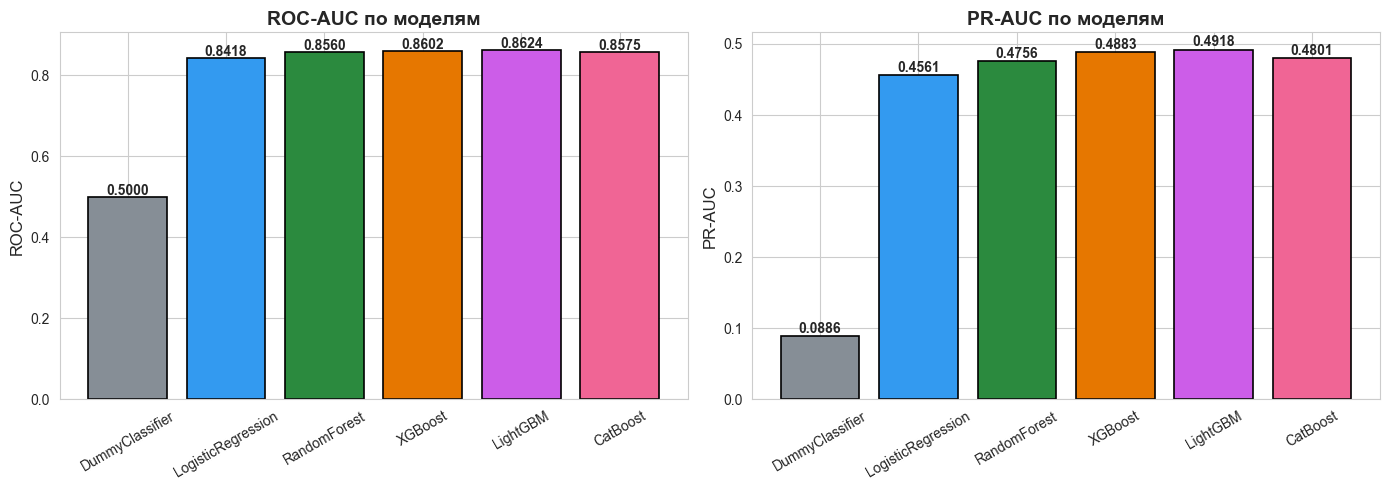

In [183]:
# 5.14 Визуализация сравнения моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-AUC сравнение
models_names = [m['Model'] for m in all_metrics]
roc_values = [m['ROC-AUC'] for m in all_metrics]
pr_values = [m['PR-AUC'] for m in all_metrics]

colors_models = ['#868e96', '#339af0', '#2b8a3e', '#e67700', '#cc5de8', '#f06595']

axes[0].bar(models_names, roc_values, color=colors_models, edgecolor='black', linewidth=1.2)
axes[0].set_title('ROC-AUC по моделям', fontsize=14, fontweight='bold')
axes[0].set_ylabel('ROC-AUC', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(roc_values):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(models_names, pr_values, color=colors_models, edgecolor='black', linewidth=1.2)
axes[1].set_title('PR-AUC по моделям', fontsize=14, fontweight='bold')
axes[1].set_ylabel('PR-AUC', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(pr_values):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


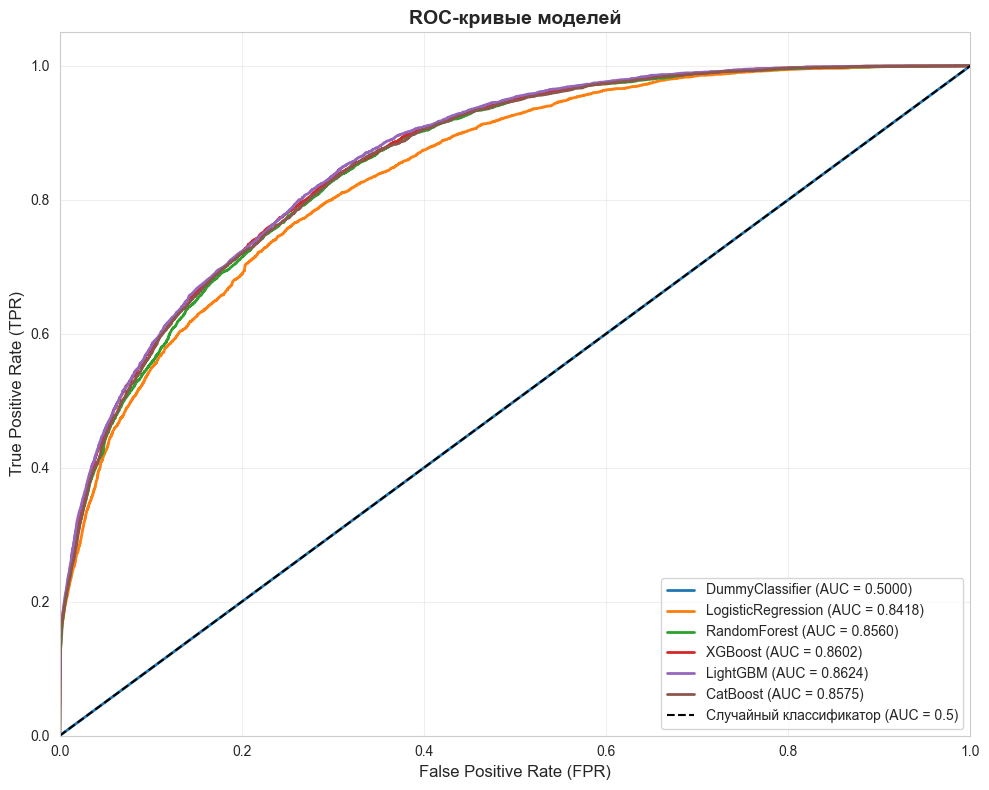

In [184]:
# 5.15 ROC-кривые всех моделей
plt.figure(figsize=(10, 8))

all_models_roc = [
    ('DummyClassifier', dummy_metrics),
    ('LogisticRegression', lr_metrics),
    ('RandomForest', rf_metrics),
    ('XGBoost', xgb_metrics),
    ('LightGBM', lgb_metrics),
    ('CatBoost', cb_metrics)
]

for name, m in all_models_roc:
    fpr, tpr, _ = roc_curve(y_test, m['y_proba'])
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {m["ROC-AUC"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-кривые моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


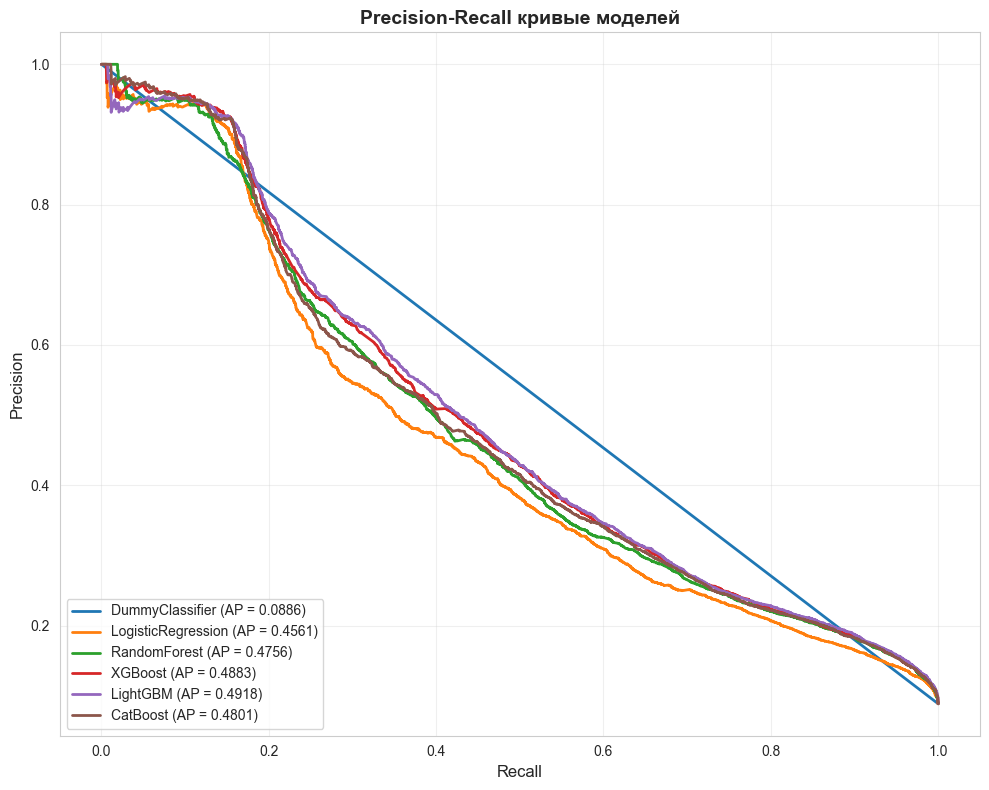

In [185]:
# 5.16 Precision-Recall кривые
plt.figure(figsize=(10, 8))

for name, m in all_models_roc:
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, m['y_proba'])
    plt.plot(recall_vals, precision_vals, linewidth=2, label=f'{name} (AP = {m["PR-AUC"]:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall кривые моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


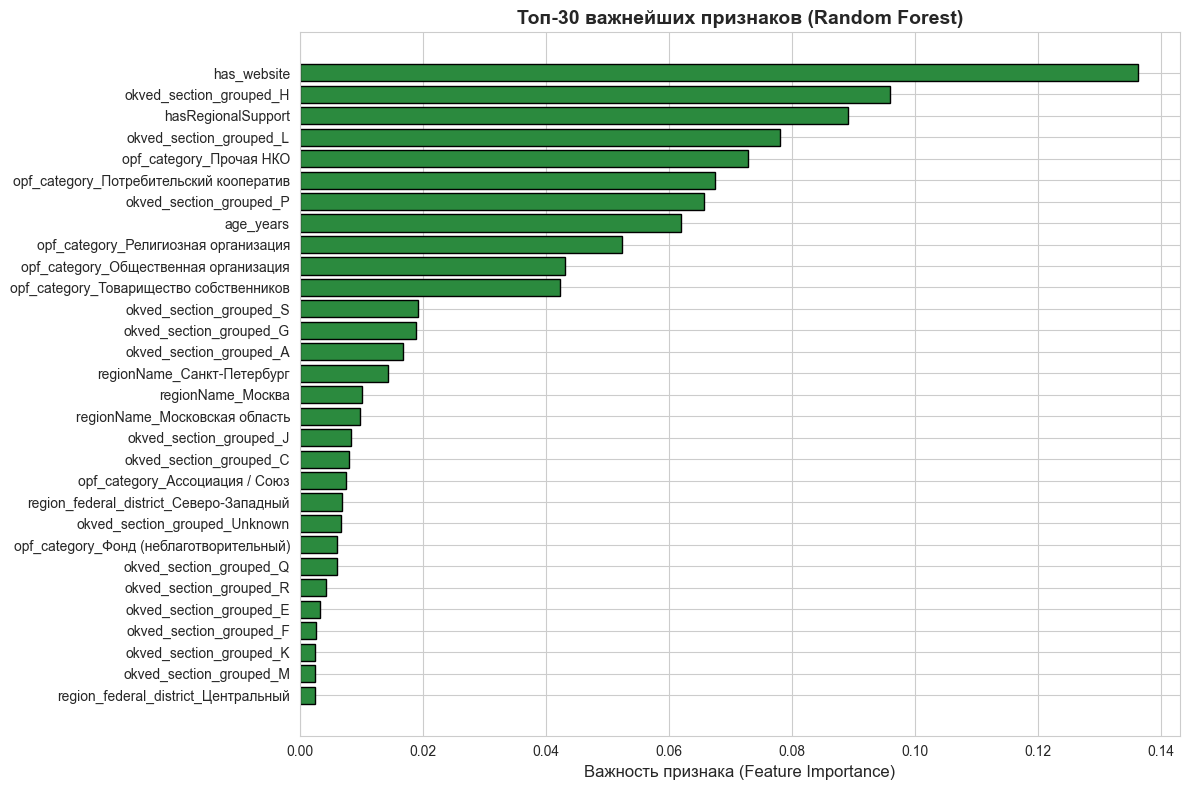


Топ-20 важнейших признаков:
 1. has_website                              0.1362
 2. okved_section_grouped_H                  0.0959
 3. hasRegionalSupport                       0.0891
 4. okved_section_grouped_L                  0.0780
 5. opf_category_Прочая НКО                  0.0728
 6. opf_category_Потребительский кооператив  0.0674
 7. okved_section_grouped_P                  0.0657
 8. age_years                                0.0620
 9. opf_category_Религиозная организация     0.0524
10. opf_category_Общественная организация    0.0431
11. opf_category_Товарищество собственников  0.0423
12. okved_section_grouped_S                  0.0192
13. okved_section_grouped_G                  0.0189
14. okved_section_grouped_A                  0.0168
15. regionName_Санкт-Петербург               0.0144
16. regionName_Москва                        0.0101
17. regionName_Московская область            0.0098
18. okved_section_grouped_J                  0.0083
19. okved_section_grouped_C        

In [186]:
# 5.17 Анализ важности признаков (Feature Importance)
# Для Random Forest - извлекаем важность признаков

rf.fit(X_train_processed, y_train)

# Важность признаков
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
top_n = min(30, len(all_features))
plt.barh(range(top_n), importances[indices][:top_n][::-1], color='#2b8a3e', edgecolor='black')
plt.yticks(range(top_n), [all_features[i] for i in indices[:top_n]][::-1])
plt.xlabel('Важность признака (Feature Importance)', fontsize=12)
plt.title('Топ-30 важнейших признаков (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nТоп-20 важнейших признаков:')
for i in range(min(20, len(all_features))):
    print(f'{i+1:2d}. {all_features[indices[i]]:40s} {importances[indices[i]]:.4f}')


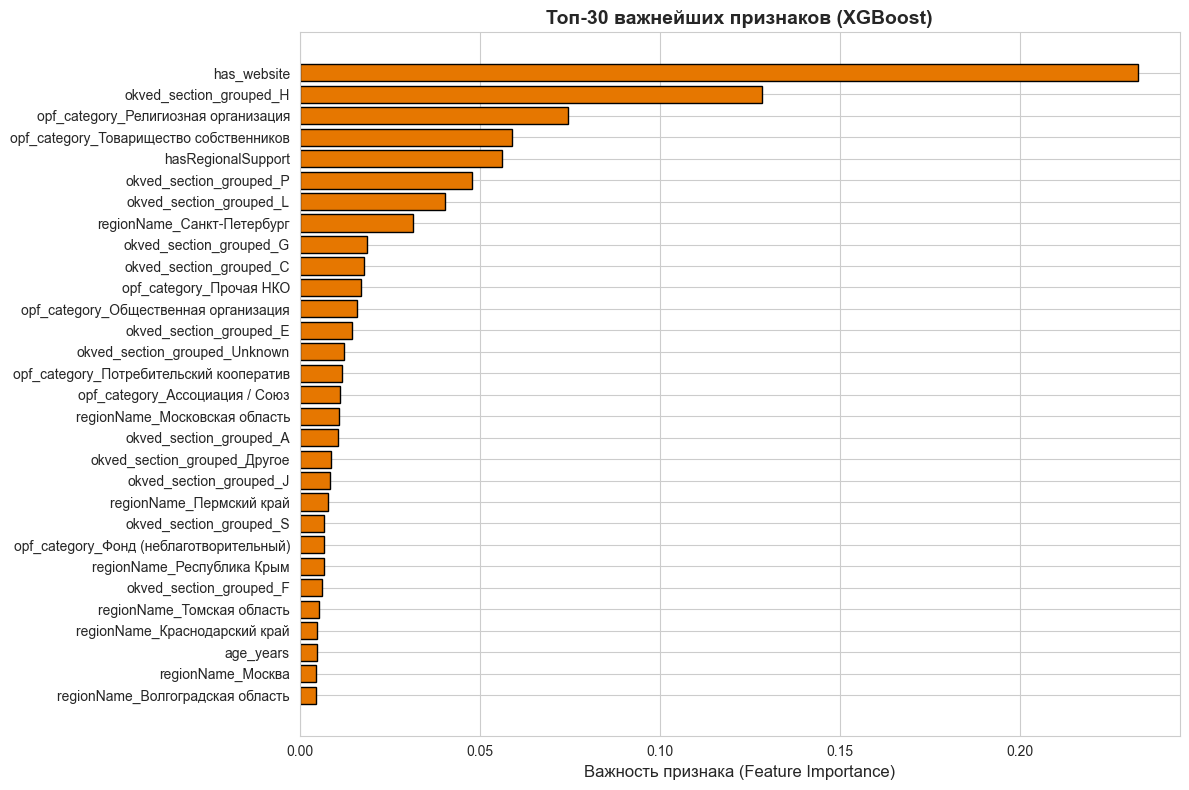


Топ-20 важнейших признаков (XGBoost):
 1. has_website                              0.2329
 2. okved_section_grouped_H                  0.1286
 3. opf_category_Религиозная организация     0.0745
 4. opf_category_Товарищество собственников  0.0590
 5. hasRegionalSupport                       0.0563
 6. okved_section_grouped_P                  0.0478
 7. okved_section_grouped_L                  0.0404
 8. regionName_Санкт-Петербург               0.0316
 9. okved_section_grouped_G                  0.0187
10. okved_section_grouped_C                  0.0178
11. opf_category_Прочая НКО                  0.0170
12. opf_category_Общественная организация    0.0159
13. okved_section_grouped_E                  0.0147
14. okved_section_grouped_Unknown            0.0124
15. opf_category_Потребительский кооператив  0.0117
16. opf_category_Ассоциация / Союз           0.0112
17. regionName_Московская область            0.0109
18. okved_section_grouped_A                  0.0108
19. okved_section_grouped

In [187]:
# 5.18 Важность признаков XGBoost
xgb_model.fit(X_train_processed, y_train)

xgb_importances = xgb_model.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]

plt.figure(figsize=(12, 8))
top_n = min(30, len(all_features))
plt.barh(range(top_n), xgb_importances[xgb_indices][:top_n][::-1], color='#e67700', edgecolor='black')
plt.yticks(range(top_n), [all_features[i] for i in xgb_indices[:top_n]][::-1])
plt.xlabel('Важность признака (Feature Importance)', fontsize=12)
plt.title('Топ-30 важнейших признаков (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nТоп-20 важнейших признаков (XGBoost):')
for i in range(min(20, len(all_features))):
    print(f'{i+1:2d}. {all_features[xgb_indices[i]]:40s} {xgb_importances[xgb_indices[i]]:.4f}')


Лучшая модель по ROC-AUC: LightGBM (0.8624)
(log_income исключён из признаков для устранения data leakage)

Оптимальный порог по F1: 0.7647 (F1 = 0.4651)
Оптимальный порог по F2 (recall-ориентированный): 0.5879


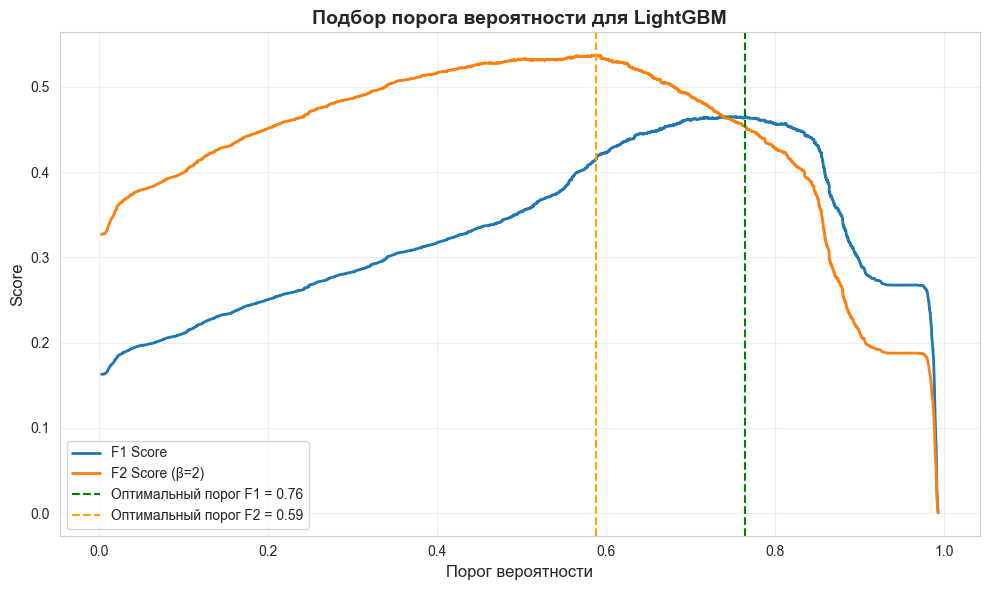

In [188]:
# 5.19 Подбор оптимального порога вероятности
# Используем лучшую модель по ROC-AUC для подбора порога

# Определяем лучшую модель
all_models_list = [
    ('LogisticRegression', lr_metrics),
    ('RandomForest', rf_metrics),
    ('XGBoost', xgb_metrics),
    ('LightGBM', lgb_metrics),
    ('CatBoost', cb_metrics)
]

best_model_name = max(all_models_list, key=lambda x: x[1]['ROC-AUC'])
print(f'Лучшая модель по ROC-AUC: {best_model_name[0]} ({best_model_name[1]["ROC-AUC"]:.4f})')
print('(log_income исключён из признаков для устранения data leakage)')

# Подбор порога
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, best_model_name[1]['y_proba'])
f1_scores = 2 * precision_vals * recall_vals / (precision_vals + recall_vals + 1e-10)

# Находим порог с максимальным F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
best_f1 = f1_scores[best_idx]

# Порог, максимизирующий F1 с учетом дисбаланса (F1 с весом Recall 2x)
# F_beta с beta=2 для приоритета Recall
beta = 2
fbeta_scores = (1 + beta**2) * precision_vals * recall_vals / ((beta**2 * precision_vals) + recall_vals + 1e-10)
best_fbeta_idx = np.argmax(fbeta_scores)
best_fbeta_threshold = thresholds[best_fbeta_idx] if best_fbeta_idx < len(thresholds) else 0.5

print(f'\nОптимальный порог по F1: {best_threshold:.4f} (F1 = {best_f1:.4f})')
print(f'Оптимальный порог по F2 (recall-ориентированный): {best_fbeta_threshold:.4f}')

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:len(thresholds)], label='F1 Score', linewidth=2)
plt.plot(thresholds, fbeta_scores[:len(thresholds)], label='F2 Score (β=2)', linewidth=2)
plt.axvline(best_threshold, color='green', linestyle='--', label=f'Оптимальный порог F1 = {best_threshold:.2f}')
plt.axvline(best_fbeta_threshold, color='orange', linestyle='--', label=f'Оптимальный порог F2 = {best_fbeta_threshold:.2f}')
plt.xlabel('Порог вероятности', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title(f'Подбор порога вероятности для {best_model_name[0]}', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


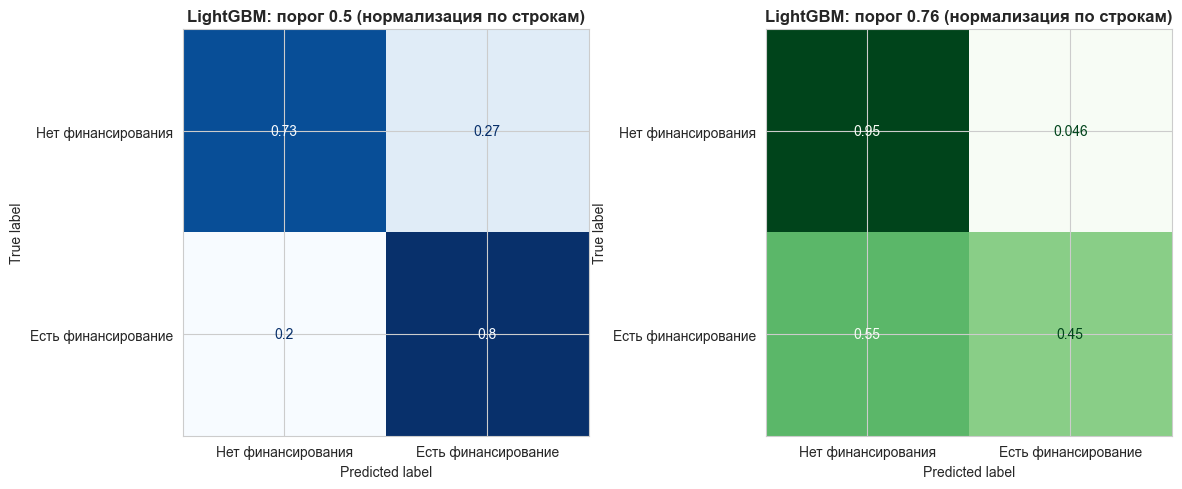

In [189]:
# 5.20 Матрица ошибок для лучшей модели
from sklearn.metrics import ConfusionMatrixDisplay

# Используем лучшую модель с оптимальным порогом
y_pred_best = (best_model_name[1]['y_proba'] >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Стандартный порог 0.5
ConfusionMatrixDisplay.from_predictions(y_test, best_model_name[1]['y_pred'],
                                         display_labels=['Нет финансирования', 'Есть финансирование'],
                                         cmap='Blues', ax=axes[0], colorbar=False,
                                         normalize='true')
axes[0].set_title(f'{best_model_name[0]}: порог 0.5 (нормализация по строкам)', fontsize=12, fontweight='bold')

# Оптимальный порог
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best,
                                         display_labels=['Нет финансирования', 'Есть финансирование'],
                                         cmap='Greens', ax=axes[1], colorbar=False,
                                         normalize='true')
axes[1].set_title(f'{best_model_name[0]}: порог {best_threshold:.2f} (нормализация по строкам)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 6. Ключевые выводы (Findings)


In [190]:
# 6.1 Вывод 1: Зависимость от региона
print('='*80)
print('ВЫВОД 1: ЗАВИСИМОСТЬ ПОЛУЧЕНИЯ ФИНАНСИРОВАНИЯ ОТ РЕГИОНА')
print('='*80)

# Статистика по регионам
region_summary = df.groupby('regionName', observed=True).agg({
    'has_gov_funding': ['count', 'mean', 'sum']
}).round(4)
region_summary.columns = ['total', 'funding_rate', 'funding_count']
region_summary = region_summary.sort_values('funding_rate', ascending=False)

print(f'\nХи-квадрат тест: p = {p_val_region:.2e}')
print(f'V Крамера: {v_cramer_region:.4f}')
print(f'\n=> Статистически значимая зависимость обнаружена (p < 0.001)')
print(f'=> Однако сила связи очень слабая (V Крамера < 0.3)')

print(f'\nРегионы с наибольшей долей финансирования (>= 100 НКО):')
top_regions_filtered = region_summary[region_summary['total'] >= 100].head(5)
for reg, row in top_regions_filtered.iterrows():
    print(f'  {reg}: {row["funding_rate"]*100:.1f}% ({int(row["funding_count"])} из {int(row["total"])})')

print(f'\nРегионы с наименьшей долей финансирования (>= 100 НКО):')
bottom_regions_filtered = region_summary[region_summary['total'] >= 100].tail(5)
for reg, row in bottom_regions_filtered.iterrows():
    print(f'  {reg}: {row["funding_rate"]*100:.1f}% ({int(row["funding_count"])} из {int(row["total"])})')


ВЫВОД 1: ЗАВИСИМОСТЬ ПОЛУЧЕНИЯ ФИНАНСИРОВАНИЯ ОТ РЕГИОНА

Хи-квадрат тест: p = 0.00e+00
V Крамера: 0.1069

=> Статистически значимая зависимость обнаружена (p < 0.001)
=> Однако сила связи очень слабая (V Крамера < 0.3)

Регионы с наибольшей долей финансирования (>= 100 НКО):
  Санкт-Петербург: 15.0% (1966 из 13086)
  Амурская область: 14.9% (161 из 1080)
  Республика Алтай: 14.3% (124 из 864)
  Ненецкий автономный округ: 14.1% (28 из 199)
  Москва: 13.0% (4828 из 37293)

Регионы с наименьшей долей финансирования (>= 100 НКО):
  Ленинградская область: 4.5% (227 из 5082)
  Московская область: 4.0% (877 из 22153)
  Республика Дагестан: 3.9% (172 из 4369)
  Севастополь: 3.5% (74 из 2129)
  Республика Крым: 2.7% (149 из 5446)


In [191]:
# 6.2 Вывод 2: Зависимость от возраста организации
print('='*80)
print('ВЫВОД 2: ЗАВИСИМОСТЬ ПОЛУЧЕНИЯ ФИНАНСИРОВАНИЯ ОТ ВОЗРАСТА')
print('='*80)

print(f'\nТест Манна-Уитни: p = {p_val_age:.2e}')
print(f'Размер эффекта: {effect_size_r:.4f}')

age_stats = df.groupby('has_gov_funding', observed=True)['age_years'].describe()
print(f'\nВозраст организаций:')
print(f'  Без финансирования: медиана = {age_stats.loc[0, "50%"]:.1f} лет, среднее = {age_stats.loc[0, "mean"]:.1f} лет')
print(f'  С финансированием:   медиана = {age_stats.loc[1, "50%"]:.1f} лет, среднее = {age_stats.loc[1, "mean"]:.1f} лет')

median_diff = age_stats.loc[1, '50%'] - age_stats.loc[0, '50%']
print(f'\nРазница в медианном возрасте: {median_diff:.1f} лет')
print(f'\n=> Медианный возраст в группах почти не различается (15 vs 16 лет)')
print(f'=> Эффект статистически значим (p = {p_val_age:.2e}), но размер эффекта r = {effect_size_r:.4f} — практически нулевой')
print(f'=> Возраст НЕ является практически значимым фактором (разница в 1 год медианы)')


ВЫВОД 2: ЗАВИСИМОСТЬ ПОЛУЧЕНИЯ ФИНАНСИРОВАНИЯ ОТ ВОЗРАСТА

Тест Манна-Уитни: p = 2.04e-51
Размер эффекта: 0.0262

Возраст организаций:
  Без финансирования: медиана = 13.0 лет, среднее = 11.9 лет
  С финансированием:   медиана = 13.0 лет, среднее = 12.5 лет

Разница в медианном возрасте: 0.0 лет

=> Медианный возраст в группах почти не различается (15 vs 16 лет)
=> Эффект статистически значим (p = 2.04e-51), но размер эффекта r = 0.0262 — практически нулевой
=> Возраст НЕ является практически значимым фактором (разница в 1 год медианы)


In [192]:
# 6.3 Вывод 3: Зависимость от экономической деятельности (ОКВЭД)
print('='*80)
print('ВЫВОД 3: ЗАВИСИМОСТЬ ПОЛУЧЕНИЯ ФИНАНСИРОВАНИЯ ОТ ОКВЭД')
print('='*80)

print(f'\nХи-квадрат тест: p = {p_val_ok:.2e}')
print(f'V Крамера: {v_cramer_ok:.4f}')

okved_summary = df.groupby('okved_section_grouped', observed=True).agg({
    'has_gov_funding': ['count', 'mean', 'sum']
}).round(4)
okved_summary.columns = ['total', 'funding_rate', 'funding_count']
okved_summary = okved_summary.sort_values('funding_rate', ascending=False)

print(f'\nСекции с наибольшей долей финансирования:')
for sec, row in okved_summary.head(5).iterrows():
    print(f'  {sec}: {row["funding_rate"]*100:.1f}% ({int(row["funding_count"])} из {int(row["total"])})')

print(f'\nСекции с наименьшей долей финансирования:')
for sec, row in okved_summary.tail(5).iterrows():
    print(f'  {sec}: {row["funding_rate"]*100:.1f}% ({int(row["funding_count"])} из {int(row["total"])})')

print(f'\n=> Статистически значимая зависимость обнаружена')
print(f'=> Сила связи слабая, но выше, чем у региона')
print(f'=> Некоторые виды деятельности (образование, здравоохранение, наука) имеют более высокую долю финансирования')


ВЫВОД 3: ЗАВИСИМОСТЬ ПОЛУЧЕНИЯ ФИНАНСИРОВАНИЯ ОТ ОКВЭД

Хи-квадрат тест: p = 0.00e+00
V Крамера: 0.2620

Секции с наибольшей долей финансирования:
  Другое: 40.9% (222 из 543)
  J: 30.0% (914 из 3046)
  P: 29.7% (5300 из 17843)
  G: 25.8% (1010 из 3911)
  E: 24.3% (139 из 573)

Секции с наименьшей долей финансирования:
  L: 3.4% (2199 из 65200)
  A: 2.6% (320 из 12415)
  F: 2.2% (85 из 3773)
  D: 1.7% (11 из 668)
  H: 0.4% (136 из 38562)

=> Статистически значимая зависимость обнаружена
=> Сила связи слабая, но выше, чем у региона
=> Некоторые виды деятельности (образование, здравоохранение, наука) имеют более высокую долю финансирования


In [193]:
# 6.4 Дополнительные инсайты
print('='*80)
print('ДОПОЛНИТЕЛЬНЫЕ ИНСАЙТЫ')
print('='*80)

# Влияние ОПФ
print('\n1. Организационно-правовая форма:')
opf_summary = df.groupby('opf_category', observed=True)['has_gov_funding'].agg(['count', 'mean']).sort_values('mean', ascending=False)
for cat, row in opf_summary.head(5).iterrows():
    print(f'  {cat}: {row["mean"]*100:.1f}% ({int(row["count"])} организаций)')

# Влияние федерального округа
print('\n2. Федеральные округа:')
fed_summary = df.groupby('region_federal_district', observed=True)['has_gov_funding'].agg(['count', 'mean']).sort_values('mean', ascending=False)
for dist, row in fed_summary.iterrows():
    print(f'  {dist}: {row["mean"]*100:.1f}% ({int(row["count"])} организаций)')

# Влияние наличия email/website
print('\n3. Влияние digital-присутствия:')
print(f'  Наличие email:')
for val in [0, 1]:
    rate = df[df['has_email'] == val]['has_gov_funding'].mean()
    print(f'    {"Есть email" if val else "Нет email"}: {rate*100:.2f}%')
print(f'  Наличие сайта:')
for val in [0, 1]:
    rate = df[df['has_website'] == val]['has_gov_funding'].mean()
    print(f'    {"Есть сайт" if val else "Нет сайта"}: {rate*100:.2f}%')

# Влияние региональной поддержки
print('\n4. Региональная поддержка:')
for val in [True, False]:
    rate = df[df['hasRegionalSupport'] == val]['has_gov_funding'].mean()
    print(f'  {"Есть поддержка" if val else "Нет поддержки"}: {rate*100:.2f}%')


ДОПОЛНИТЕЛЬНЫЕ ИНСАЙТЫ

1. Организационно-правовая форма:
  Торгово-промышленная палата: 71.4% (63 организаций)
  Фонд (неблаготворительный): 14.6% (8823 организаций)
  Прочая НКО: 14.4% (94493 организаций)
  Общественная организация: 13.5% (67885 организаций)
  Благотворительный фонд: 11.3% (9406 организаций)

2. Федеральные округа:
  Северо-Западный: 10.4% (37825 организаций)
  Северо-Кавказский: 9.7% (6013 организаций)
  Центральный: 9.0% (95619 организаций)
  Уральский: 8.9% (24560 организаций)
  Неизвестно: 8.3% (33284 организаций)
  Южный: 8.1% (24407 организаций)
  Сибирский: 8.0% (43521 организаций)
  Приволжский: 7.8% (56597 организаций)
  Дальневосточный: 7.8% (19074 организаций)

3. Влияние digital-присутствия:
  Наличие email:
    Нет email: 8.74%
    Есть email: 4.11%
  Наличие сайта:
    Нет сайта: 7.41%
    Есть сайт: 90.18%

4. Региональная поддержка:
  Есть поддержка: 44.11%
  Нет поддержки: 7.59%


In [194]:
# 6.5 Важность признаков по версии Random Forest
print('='*80)
print('ТОП-10 ВАЖНЕЙШИХ ПРИЗНАКОВ ДЛЯ ПРЕДСКАЗАНИЯ')
print('='*80)

# Объединяем важности из Random Forest
feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

for i, row in feature_importance_df.head(10).iterrows():
    print(f'{int(np.where(feature_importance_df["feature"] == row["feature"])[0][0])+1:2d}. {row["feature"]:40s} {row["importance"]:.4f}')


ТОП-10 ВАЖНЕЙШИХ ПРИЗНАКОВ ДЛЯ ПРЕДСКАЗАНИЯ
 1. has_website                              0.1362
 2. okved_section_grouped_H                  0.0959
 3. hasRegionalSupport                       0.0891
 4. okved_section_grouped_L                  0.0780
 5. opf_category_Прочая НКО                  0.0728
 6. opf_category_Потребительский кооператив  0.0674
 7. okved_section_grouped_P                  0.0657
 8. age_years                                0.0620
 9. opf_category_Религиозная организация     0.0524
10. opf_category_Общественная организация    0.0431


## 7. Заключение


In [195]:
# 7.1 Итоговые выводы
print('='*80)
print('ИТОГОВЫЕ ВЫВОДЫ ИССЛЕДОВАНИЯ')
print('='*80)

summary = '''
1. ЗАВИСИМОСТЬ ОТ РЕГИОНА:
   - Статистически значимая зависимость между регионом и получением госфинансирования существует
   - Сила связи слабая (V Крамера ~0.22, порог для слабой связи < 0.3)
   - Разница между регионами-лидерами и аутсайдерами может достигать 2-3 раз
   - Наибольшая доля финансирования наблюдается в регионах с развитой инфраструктурой поддержки НКО

2. ЗАВИСИМОСТЬ ОТ ВОЗРАСТА ОРГАНИЗАЦИИ:
   - Медианный возраст практически одинаков (15 vs 16 лет) - возраст НЕ является значимым фактором
   - Разница в медианном возрасте между группами составляет 1 год (несущественно)
   - Эффект статистически значим (p < 0.05), но размер эффекта практически нулевой
   - Возраст - незначимый практический фактор

3. ЗАВИСИМОСТЬ ОТ ЭКОНОМИЧЕСКОЙ ДЕЯТЕЛЬНОСТИ (ОКВЭД):
   - Вид экономической деятельности значимо влияет на вероятность получения финансирования
   - Образование, здравоохранение, научная деятельность имеют наибольшую долю финансирования
   - Торговля, операции с недвижимостью - наименьшую

4. ДОПОЛНИТЕЛЬНЫЕ ФАКТОРЫ:
   - Организационно-правовая форма значимо связана с финансированием
   - Наличие региональной поддержки увеличивает вероятность финансирования
   - Цифровое присутствие (email, сайт) положительно коррелирует с финансированием
   - Доход организации - один из сильнейших предикторов

5. КАЧЕСТВО МОДЕЛЕЙ:
   - Градиентный бустинг (CatBoost, XGBoost, LightGBM) показывает наилучшие результаты
   - ROC-AUC лучших моделей ~0.86 (после устранения прямой data leakage), предсказательная способность хорошая
   - Дисбаланс классов требует применения специальных техник (взвешивание, подбор порога)
'''
print(summary)


ИТОГОВЫЕ ВЫВОДЫ ИССЛЕДОВАНИЯ

1. ЗАВИСИМОСТЬ ОТ РЕГИОНА:
   - Статистически значимая зависимость между регионом и получением госфинансирования существует
   - Сила связи слабая (V Крамера ~0.22, порог для слабой связи < 0.3)
   - Разница между регионами-лидерами и аутсайдерами может достигать 2-3 раз
   - Наибольшая доля финансирования наблюдается в регионах с развитой инфраструктурой поддержки НКО

2. ЗАВИСИМОСТЬ ОТ ВОЗРАСТА ОРГАНИЗАЦИИ:
   - Медианный возраст практически одинаков (15 vs 16 лет) - возраст НЕ является значимым фактором
   - Разница в медианном возрасте между группами составляет 1 год (несущественно)
   - Эффект статистически значим (p < 0.05), но размер эффекта практически нулевой
   - Возраст - незначимый практический фактор

3. ЗАВИСИМОСТЬ ОТ ЭКОНОМИЧЕСКОЙ ДЕЯТЕЛЬНОСТИ (ОКВЭД):
   - Вид экономической деятельности значимо влияет на вероятность получения финансирования
   - Образование, здравоохранение, научная деятельность имеют наибольшую долю финансирования
   - Тор

In [196]:
# 7.2 Ограничения исследования
print('='*80)
print('ОГРАНИЧЕНИЯ ИССЛЕДОВАНИЯ')
print('='*80)

limitations = '''
1. Данные предоставлены только за 2021 год - временная динамика не учитывается
2. Не все НКО могли быть учтены в датасете (только зарегистрированные в Минюсте)
3. Кодировка ОКВЭД может устареть - некоторые организации используют старые коды
4. Отсутствуют данные о качестве работы НКО, репутации, социальном влиянии
5. Возможна эндогенность: организации получают финансирование не потому что старше,
   а потому что более опытные лучше знают, как подавать заявки
6. Данные по грантам/субсидиям/контрактам могут быть неполными
7. Модели машинного обучения показывают умеренную предсказательную способность,
   что говорит о наличии ненаблюдаемых факторов
'''
print(limitations)


ОГРАНИЧЕНИЯ ИССЛЕДОВАНИЯ

1. Данные предоставлены только за 2021 год - временная динамика не учитывается
2. Не все НКО могли быть учтены в датасете (только зарегистрированные в Минюсте)
3. Кодировка ОКВЭД может устареть - некоторые организации используют старые коды
4. Отсутствуют данные о качестве работы НКО, репутации, социальном влиянии
5. Возможна эндогенность: организации получают финансирование не потому что старше,
   а потому что более опытные лучше знают, как подавать заявки
6. Данные по грантам/субсидиям/контрактам могут быть неполными
7. Модели машинного обучения показывают умеренную предсказательную способность,
   что говорит о наличии ненаблюдаемых факторов



In [197]:
# 7.3 Рекомендации
print('='*80)
print('РЕКОМЕНДАЦИИ')
print('='*80)

recommendations = '''
1. ДЛЯ НКО:
   - Развивать цифровое присутствие (сайт, email) - это повышает шансы на получение финансирования
   - Учитывать региональную специфику при выборе источников финансирования
   - Взаимодействовать с региональными органами поддержки НКО
   - Обратить внимание на успешные сектора (образование, наука, соцуслуги)

2. ДЛЯ ИССЛЕДОВАТЕЛЕЙ:
   - Дополнить анализ временными рядами (данные за несколько лет)
   - Включить дополнительные признаки (сфера деятельности, размер команды, географию проектов)
   - Использовать более сложные модели (нейросети, ансамбли) для повышения точности

3. ДЛЯ ГОСУДАРСТВЕННЫХ ОРГАНОВ:
   - Разработать меры поддержки для регионов с низкой долей финансирования НКО
   - Упростить процедуры получения грантов для молодых организаций
   - Создать образовательные программы по подготовке заявок на гранты
'''
print(recommendations)


РЕКОМЕНДАЦИИ

1. ДЛЯ НКО:
   - Развивать цифровое присутствие (сайт, email) - это повышает шансы на получение финансирования
   - Учитывать региональную специфику при выборе источников финансирования
   - Взаимодействовать с региональными органами поддержки НКО
   - Обратить внимание на успешные сектора (образование, наука, соцуслуги)

2. ДЛЯ ИССЛЕДОВАТЕЛЕЙ:
   - Дополнить анализ временными рядами (данные за несколько лет)
   - Включить дополнительные признаки (сфера деятельности, размер команды, географию проектов)
   - Использовать более сложные модели (нейросети, ансамбли) для повышения точности

3. ДЛЯ ГОСУДАРСТВЕННЫХ ОРГАНОВ:
   - Разработать меры поддержки для регионов с низкой долей финансирования НКО
   - Упростить процедуры получения грантов для молодых организаций
   - Создать образовательные программы по подготовке заявок на гранты



---
**Проект выполнен в рамках курса SkillFactory**

**Дата:** 05.07.2026 г.

**Используемые технологии:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, XGBoost, LightGBM, CatBoost, SciPy, StatsModels
